<a href="https://colab.research.google.com/github/enikulchev/EN/blob/main/Phys_Lett_A_Rossler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating Rossler data...
Unstable focus: x0=0.007026, y0=-0.035131, z0=0.035131

--- Identification in V4 basis ---

dX/dt (V4):
  X           +0.084864
  YZ          -0.496789
  X^3         -0.002468
  XY^2        +0.011988
  XZ^2        -0.007361
  X^2YZ       +0.003098
  Y^3Z        -0.005160
  YZ^3        +0.000563

dY/dt (V4):
  Y           +0.427787
  XZ          +0.593865
  Y^3         -0.003297
  YX^2        -0.017691
  YZ^2        -0.026436
  XY^2Z       +0.000272
  X^3Z        -0.004032
  XZ^3        -0.000645

dZ/dt (V4):
  Z           -5.489080
  XY          +0.009601
  Z^3         +0.002095
  ZX^2        +0.099441
  ZY^2        +0.038526
  XYZ^2       +0.008045
  XY^3        -0.000193

--- Residual decomposition ---

dX/dt residual contributions (MSE 1.819e+01 -> 4.940e+00):
  Z             -0.747296
  XY            +0.076858
  XZ            +0.059472
  Y^2Z          +0.038320
  Y^2           -0.021739
  X^2           -0.012246
  Y^3           -0.011948
  X^2Y          -

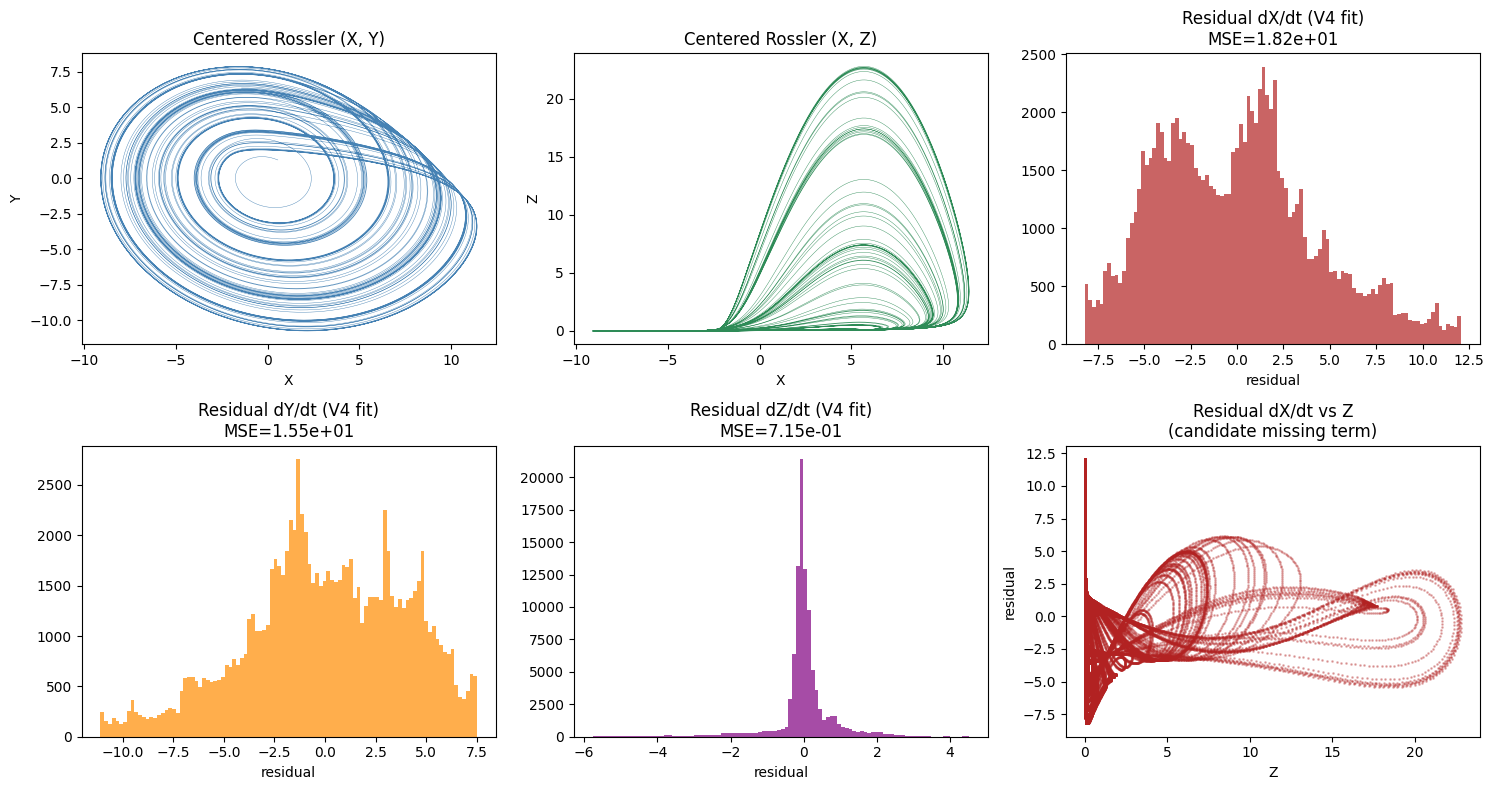

In [2]:
"""
V4-equivariant skeleton of Rossler spiral chaos.
Experiment: decomposition into symmetric skeleton + non-equivariant residual.
"""

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# ============================================================
# 1. Rossler system and centering
# ============================================================

A_ROSS = 0.2
B_ROSS = 0.2
C_ROSS = 5.7


def rossler(t, s):
    x, y, z = s
    return [-y - z,
             x + A_ROSS * y,
             B_ROSS + z * (x - C_ROSS)]


def find_unstable_focus():
    """Solve a*z^2 - c*z + b = 0 for the inner focus."""
    a, b, c = A_ROSS, B_ROSS, C_ROSS
    disc = c * c - 4 * a * b
    z1 = (c + np.sqrt(disc)) / (2 * a)
    z2 = (c - np.sqrt(disc)) / (2 * a)
    z0 = z2  # inner focus
    y0 = -z0
    x0 = -a * y0
    return x0, y0, z0


def generate_data(T=500.0, dt=0.005, ic=(1.0, 1.0, 1.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(rossler, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y.T  # (N, 3)


def center_data(X, x0, y0, z0):
    return X - np.array([x0, y0, z0])


# ============================================================
# 2. Numerical derivatives
# ============================================================

def central_diff(X, dt):
    """Central differences for the first derivative."""
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0] = (X[1] - X[0]) / dt
    dX[-1] = (X[-1] - X[-2]) / dt
    return dX


# ============================================================
# 3. V4 equivariant basis (degree <= 3)
# ============================================================

def v4_basis(X, Y, Z):
    """
    Returns the 24 monomials of the V4-equivariant basis (degree <= 3),
    grouped by component (8 monomials each).
    """
    Fu = [
        X,                 # u
        Y * Z,             # vw
        X**3,              # u^3
        X * Y**2,          # u v^2
        X * Z**2,          # u w^2
        X**2 * Y * Z,      # u^2 v w
        Y**3 * Z,          # v^3 w
        Y * Z**3,          # v w^3
    ]
    Fv = [
        Y,
        X * Z,
        Y**3,
        Y * X**2,
        Y * Z**2,
        X * Y**2 * Z,
        X**3 * Z,
        X * Z**3,
    ]
    Fw = [
        Z,
        X * Y,
        Z**3,
        Z * X**2,
        Z * Y**2,
        X * Y * Z**2,
        X**3 * Y,
        X * Y**3,
    ]
    return Fu, Fv, Fw


def full_poly_basis(X, Y, Z, degree=3):
    """
    Full polynomial basis of degree <= d (all monomials).
    Used as SINDy baseline.
    """
    monos = []
    names = []
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            for k in range(degree + 1 - i - j):
                monos.append((X**i) * (Y**j) * (Z**k))
                names.append(f"X^{i}Y^{j}Z^{k}")
    return monos, names


def non_equivariant_corrections_named(X, Y, Z):
    """
    Returns monomials and names for non-V4 terms in centered Rossler.
    Key terms: -Z in dX/dt, +X in dY/dt, z0*X and X*Z in dZ/dt.
    """
    data = {
        "dX": (
            [Z, X*Z, Y*Z**2, X**2*Y, X*Y, Y**2*Z, Z**3, Y**3, X**2, Y**2],
            ["Z", "XZ", "YZ^2", "X^2Y", "XY", "Y^2Z", "Z^3", "Y^3", "X^2", "Y^2"]
        ),
        "dY": (
            [X, X*Y, X**2*Z, Y**2*Z, Y*Z, Z**2, X**3, Y**3, X**2, Y**2],
            ["X", "XY", "X^2Z", "Y^2Z", "YZ", "Z^2", "X^3", "Y^3", "X^2", "Y^2"]
        ),
        "dZ": (
            [X, X*Z, X**2, Y**2, X*Y*Z, X**2*Y, X*Y**2, Z**2, Z*X*Y, Z**3],
            ["X", "XZ", "X^2", "Y^2", "XYZ", "X^2Y", "XY^2", "Z^2", "XYZ_alt", "Z^3"]
        ),
    }
    return data


# ============================================================
# 4. Sparse identification (STLSQ)
# ============================================================

def stlsq(Theta, dX, threshold=1e-2, max_iter=10):
    """Sequential thresholded least squares."""
    coef = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(max_iter):
        small = np.abs(coef) < threshold
        if not small.any():
            break
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef[big] = np.linalg.lstsq(Theta[:, big], dX, rcond=None)[0]
    return coef


def identify(Theta, dX, threshold=1e-2):
    """Identify one component with STLSQ + standardization."""
    scaler = StandardScaler()
    Theta_s = scaler.fit_transform(Theta)
    coef = stlsq(Theta_s, dX, threshold=threshold)
    coef = coef / scaler.scale_
    intercept = -np.sum(coef * scaler.mean_)
    return coef, intercept


def build_design(basis_list):
    return np.column_stack(basis_list)


# ============================================================
# 5. Residual decomposition
# ============================================================

def decompose_residual(d_true, coef_v4, intercept_v4, Theta_v4,
                       extra_monos, extra_names, threshold=1e-3):
    """
    Fit the residual after V4 identification with non-equivariant monomials.
    Returns: residual array, dict {name: coefficient}, MSE before/after.
    """
    pred = Theta_v4 @ coef_v4 + intercept_v4
    resid = d_true - pred
    mse_before = float(np.mean(resid ** 2))

    Theta_extra = build_design(extra_monos)
    coef_extra, intercept_extra = identify(Theta_extra, resid,
                                           threshold=threshold)

    contributions = {str(name): float(c)
                     for name, c in zip(extra_names, coef_extra)}

    pred_extra = Theta_extra @ coef_extra + intercept_extra
    mse_after = float(np.mean((resid - pred_extra) ** 2))

    return resid, contributions, mse_before, mse_after


# ============================================================
# 6. Lyapunov spectrum (Benettin)
# ============================================================

def jacobian_rossler(s):
    x, y, z = s
    return np.array([
        [0.0, -1.0, -1.0],
        [1.0, A_ROSS, 0.0],
        [z, 0.0, x - C_ROSS],
    ])


def lyapunov_spectrum(ic, T=800.0, dt=0.002, transient=200.0):
    """Benettin method for the Rossler system."""
    s = np.array(ic, dtype=float)
    Q = np.eye(3)
    lambdas = np.zeros(3)
    n_steps = int(T / dt)
    n_trans = int(transient / dt)

    for step in range(n_trans + n_steps):
        k1 = np.array(rossler(0, s))
        k1_Q = jacobian_rossler(s) @ Q
        s2 = s + 0.5 * dt * k1
        k2 = np.array(rossler(0, s2))
        k2_Q = jacobian_rossler(s2) @ (Q + 0.5 * dt * k1_Q)
        s3 = s + 0.5 * dt * k2
        k3 = np.array(rossler(0, s3))
        k3_Q = jacobian_rossler(s3) @ (Q + 0.5 * dt * k2_Q)
        s4 = s + dt * k3
        k4 = np.array(rossler(0, s4))
        k4_Q = jacobian_rossler(s4) @ (Q + dt * k3_Q)

        s = s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        Q = Q + (dt / 6.0) * (k1_Q + 2*k2_Q + 2*k3_Q + k4_Q)

        Q, R = np.linalg.qr(Q)
        diag = np.abs(np.diag(R))
        diag[diag < 1e-14] = 1e-14

        if step >= n_trans:
            lambdas += np.log(diag)

    return lambdas / (n_steps * dt)


# ============================================================
# 7. Main experiment
# ============================================================

def main():
    # --- data ---
    print("Generating Rossler data...")
    t, X = generate_data(T=500.0, dt=0.005, ic=(1.0, 1.0, 1.0))
    x0, y0, z0 = find_unstable_focus()
    print(f"Unstable focus: x0={x0:.6f}, y0={y0:.6f}, z0={z0:.6f}")

    Xc = center_data(X, x0, y0, z0)
    dt = t[1] - t[0]
    dXc = central_diff(Xc, dt)

    sl = slice(50, -50)
    Xs, Ys, Zs = Xc[sl, 0], Xc[sl, 1], Xc[sl, 2]
    dXs, dYs, dZs = dXc[sl, 0], dXc[sl, 1], dXc[sl, 2]

    # --- Basis 1: V4-equivariant ---
    Fu, Fv, Fw = v4_basis(Xs, Ys, Zs)
    Theta_u = build_design(Fu)
    Theta_v = build_design(Fv)
    Theta_w = build_design(Fw)

    print("\n--- Identification in V4 basis ---")
    coef_u, int_u = identify(Theta_u, dXs, threshold=1e-3)
    coef_v, int_v = identify(Theta_v, dYs, threshold=1e-3)
    coef_w, int_w = identify(Theta_w, dZs, threshold=1e-3)

    names_u = ["X", "YZ", "X^3", "XY^2", "XZ^2", "X^2YZ", "Y^3Z", "YZ^3"]
    names_v = ["Y", "XZ", "Y^3", "YX^2", "YZ^2", "XY^2Z", "X^3Z", "XZ^3"]
    names_w = ["Z", "XY", "Z^3", "ZX^2", "ZY^2", "XYZ^2", "X^3Y", "XY^3"]

    def show(names, coefs, label):
        print(f"\n{label}:")
        for n, c in zip(names, coefs):
            if abs(c) > 1e-4:
                print(f"  {n:10s}  {c:+.6f}")

    show(names_u, coef_u, "dX/dt (V4)")
    show(names_v, coef_v, "dY/dt (V4)")
    show(names_w, coef_w, "dZ/dt (V4)")

    # --- residual decomposition ---
    print("\n--- Residual decomposition ---")
    extra_data = non_equivariant_corrections_named(Xs, Ys, Zs)

    monos_u, names_u_extra = extra_data["dX"]
    resid_u, contrib_u, mse_u_before, mse_u_after = decompose_residual(
        dXs, coef_u, int_u, Theta_u, monos_u, names_u_extra)

    monos_v, names_v_extra = extra_data["dY"]
    resid_v, contrib_v, mse_v_before, mse_v_after = decompose_residual(
        dYs, coef_v, int_v, Theta_v, monos_v, names_v_extra)

    monos_w, names_w_extra = extra_data["dZ"]
    resid_w, contrib_w, mse_w_before, mse_w_after = decompose_residual(
        dZs, coef_w, int_w, Theta_w, monos_w, names_w_extra)

    for label, contrib, mb, ma in [
        ("dX", contrib_u, mse_u_before, mse_u_after),
        ("dY", contrib_v, mse_v_before, mse_v_after),
        ("dZ", contrib_w, mse_w_before, mse_w_after),
    ]:
        print(f"\n{label}/dt residual contributions "
              f"(MSE {mb:.3e} -> {ma:.3e}):")
        for mono, c in sorted(contrib.items(), key=lambda kv: -abs(kv[1])):
            if abs(c) > 1e-4:
                print(f"  {mono:12s}  {c:+.6f}")

    # --- MSE comparison with full polynomial basis ---
    print("\n--- MSE comparison ---")
    monos_full, names_full = full_poly_basis(Xs, Ys, Zs, degree=3)
    Theta_full = build_design(monos_full)

    coef_full_u, int_full_u = identify(Theta_full, dXs, threshold=1e-2)
    coef_full_v, int_full_v = identify(Theta_full, dYs, threshold=1e-2)
    coef_full_w, int_full_w = identify(Theta_full, dZs, threshold=1e-2)

    pred_full_u = Theta_full @ coef_full_u + int_full_u
    pred_full_v = Theta_full @ coef_full_v + int_full_v
    pred_full_w = Theta_full @ coef_full_w + int_full_w

    mse_full_u = float(np.mean((dXs - pred_full_u) ** 2))
    mse_full_v = float(np.mean((dYs - pred_full_v) ** 2))
    mse_full_w = float(np.mean((dZs - pred_full_w) ** 2))

    mse_v4_u = float(np.mean((dXs - (Theta_u @ coef_u + int_u)) ** 2))
    mse_v4_v = float(np.mean((dYs - (Theta_v @ coef_v + int_v)) ** 2))
    mse_v4_w = float(np.mean((dZs - (Theta_w @ coef_w + int_w)) ** 2))

    print(f"{'Component':<12s}{'V4 MSE':<15s}{'Full poly MSE':<15s}"
          f"{'Ratio':<10s}")
    for comp, m4, mf in [("dX", mse_v4_u, mse_full_u),
                         ("dY", mse_v4_v, mse_full_v),
                         ("dZ", mse_v4_w, mse_full_w)]:
        ratio = m4 / mf if mf > 0 else float('inf')
        print(f"{comp:<12s}{m4:<15.4e}{mf:<15.4e}{ratio:<10.2f}")

    # --- active terms ---
    print("\n--- Active term counts ---")
    print(f"V4  active: "
          f"dX={int((np.abs(coef_u) > 1e-3).sum())}/8, "
          f"dY={int((np.abs(coef_v) > 1e-3).sum())}/8, "
          f"dZ={int((np.abs(coef_w) > 1e-3).sum())}/8")
    print(f"Full active: "
          f"dX={int((np.abs(coef_full_u) > 1e-2).sum())}/{len(monos_full)}, "
          f"dY={int((np.abs(coef_full_v) > 1e-2).sum())}/{len(monos_full)}, "
          f"dZ={int((np.abs(coef_full_w) > 1e-2).sum())}/{len(monos_full)}")

    # --- Lyapunov spectrum of reference ---
    print("\n--- Lyapunov spectrum (reference) ---")
    lam_ref = lyapunov_spectrum((1.0, 1.0, 1.0), T=200.0, dt=0.005,
                                 transient=50.0)
    print(f"Reference Rossler: {lam_ref}")
    print("  (expected: ~[0.07, 0.0, -5.4])")

    # --- Plots ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    axes[0, 0].plot(Xs, Ys, lw=0.3, color='steelblue')
    axes[0, 0].set_title('Centered Rossler (X, Y)')
    axes[0, 0].set_xlabel('X'); axes[0, 0].set_ylabel('Y')

    axes[0, 1].plot(Xs, Zs, lw=0.3, color='seagreen')
    axes[0, 1].set_title('Centered Rossler (X, Z)')
    axes[0, 1].set_xlabel('X'); axes[0, 1].set_ylabel('Z')

    axes[0, 2].hist(resid_u, bins=100, color='firebrick', alpha=0.7)
    axes[0, 2].set_title(f'Residual dX/dt (V4 fit)\nMSE={mse_v4_u:.2e}')
    axes[0, 2].set_xlabel('residual')

    axes[1, 0].hist(resid_v, bins=100, color='darkorange', alpha=0.7)
    axes[1, 0].set_title(f'Residual dY/dt (V4 fit)\nMSE={mse_v4_v:.2e}')
    axes[1, 0].set_xlabel('residual')

    axes[1, 1].hist(resid_w, bins=100, color='purple', alpha=0.7)
    axes[1, 1].set_title(f'Residual dZ/dt (V4 fit)\nMSE={mse_v4_w:.2e}')
    axes[1, 1].set_xlabel('residual')

    # residual vs candidate monomials
    axes[1, 2].scatter(Zs, resid_u, s=1, alpha=0.3, color='firebrick')
    axes[1, 2].set_title('Residual dX/dt vs Z\n(candidate missing term)')
    axes[1, 2].set_xlabel('Z'); axes[1, 2].set_ylabel('residual')

    plt.tight_layout()
    plt.savefig('v4_rossler.png', dpi=150)
    print("\nPlot saved to v4_rossler.png")


if __name__ == "__main__":
    main()

Generating data...
Focus: x0=0.007026, y0=-0.035131, z0=0.035131

V4 residual MSE: dX=1.819e+01, dY=1.550e+01, dZ=7.151e-01

DIAGNOSTIC: what does the residual actually contain?

resid_dX ~ a*Y + b*Z
  MSE before:  1.819e+01
  MSE after:   4.352e+00
  Reduction:   4.18x
  coef Y: -0.7809
  coef Z: +0.1839
  corr(Y): -0.8643
  corr(Z): -0.0325

resid_dY ~ a*X
  MSE before:  1.550e+01
  MSE after:   6.432e+00
  Reduction:   2.41x
  coef X: +0.5850
  corr(X): +0.7649

resid_dZ ~ a*X + b*Z + c*XZ
  MSE before:  7.151e-01
  MSE after:   6.649e-01
  Reduction:   1.08x
  coef X: +0.0439
  coef Z: -0.0514
  coef XZ: +0.0043
  corr(X): +0.2476
  corr(Z): +0.0000
  corr(XZ): +0.0456

Plot saved to diagnostic.png


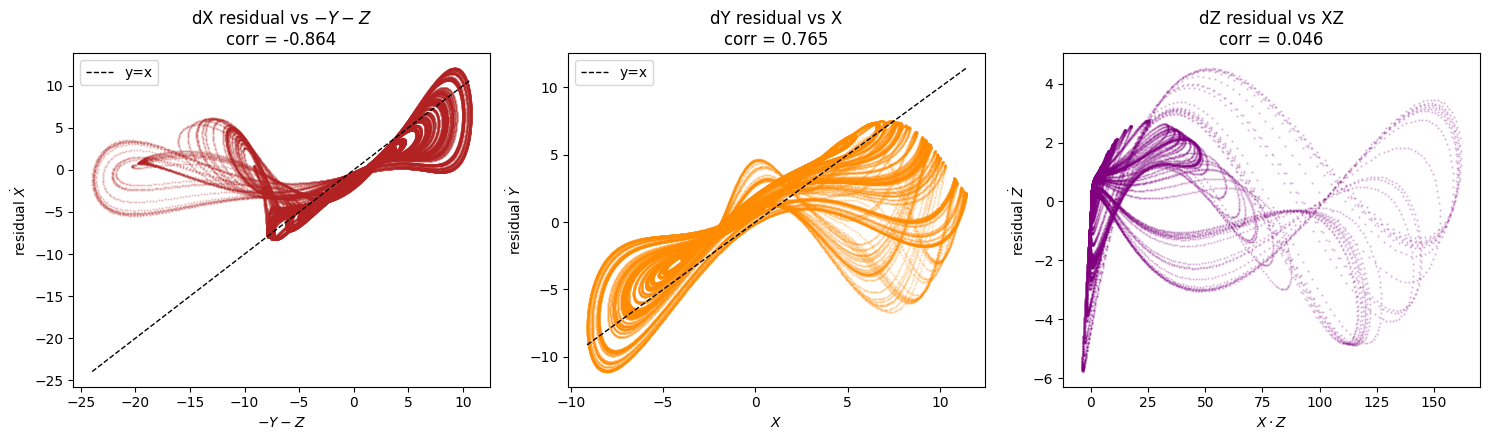

In [3]:
"""
Diagnostic: which TRUE missing terms does the V4 residual contain?
"""

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


A_ROSS, B_ROSS, C_ROSS = 0.2, 0.2, 5.7


def rossler(t, s):
    x, y, z = s
    return [-y - z, x + A_ROSS * y, B_ROSS + z * (x - C_ROSS)]


def find_unstable_focus():
    a, b, c = A_ROSS, B_ROSS, C_ROSS
    z0 = (c - np.sqrt(c*c - 4*a*b)) / (2*a)
    return -a*(-z0), -z0, z0


def generate_data(T=500.0, dt=0.005, ic=(1.0, 1.0, 1.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(rossler, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y.T


def central_diff(X, dt):
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0] = (X[1] - X[0]) / dt
    dX[-1] = (X[-1] - X[-2]) / dt
    return dX


def v4_basis(X, Y, Z):
    Fu = [X, Y*Z, X**3, X*Y**2, X*Z**2, X**2*Y*Z, Y**3*Z, Y*Z**3]
    Fv = [Y, X*Z, Y**3, Y*X**2, Y*Z**2, X*Y**2*Z, X**3*Z, X*Z**3]
    Fw = [Z, X*Y, Z**3, Z*X**2, Z*Y**2, X*Y*Z**2, X**3*Y, X*Y**3]
    return Fu, Fv, Fw


def build_design(basis_list):
    return np.column_stack(basis_list)


def stlsq(Theta, dX, threshold=1e-2, max_iter=10):
    coef = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(max_iter):
        small = np.abs(coef) < threshold
        if not small.any():
            break
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef[big] = np.linalg.lstsq(Theta[:, big], dX, rcond=None)[0]
    return coef


def identify(Theta, dX, threshold=1e-2):
    scaler = StandardScaler()
    Theta_s = scaler.fit_transform(Theta)
    coef = stlsq(Theta_s, dX, threshold=threshold)
    coef = coef / scaler.scale_
    intercept = -np.sum(coef * scaler.mean_)
    return coef, intercept


def fit_residual_with_terms(resid, terms, names):
    """
    Fit residual with a specific list of candidate monomials.
    Returns coefficients, MSE improvement, correlations.
    """
    Theta = build_design(terms)
    coef, intercept = identify(Theta, resid, threshold=1e-6)

    pred = Theta @ coef + intercept
    mse_after = float(np.mean((resid - pred) ** 2))
    mse_before = float(np.mean(resid ** 2))

    corr = {}
    for name, term in zip(names, terms):
        corr[name] = float(np.corrcoef(term, resid)[0, 1])

    return {
        'coef': dict(zip(names, coef.astype(float))),
        'corr': corr,
        'mse_before': mse_before,
        'mse_after': mse_after,
        'reduction': mse_before / mse_after if mse_after > 0 else np.inf,
    }


def main():
    print("Generating data...")
    t, X = generate_data()
    x0, y0, z0 = find_unstable_focus()
    print(f"Focus: x0={x0:.6f}, y0={y0:.6f}, z0={z0:.6f}")

    Xc = X - np.array([x0, y0, z0])
    dt = t[1] - t[0]
    dXc = central_diff(Xc, dt)

    sl = slice(50, -50)
    Xs, Ys, Zs = Xc[sl, 0], Xc[sl, 1], Xc[sl, 2]
    dXs, dYs, dZs = dXc[sl, 0], dXc[sl, 1], dXc[sl, 2]

    # ============================================================
    # STEP 1. V4 fit
    # ============================================================
    Fu, Fv, Fw = v4_basis(Xs, Ys, Zs)
    Theta_u = build_design(Fu)
    Theta_v = build_design(Fv)
    Theta_w = build_design(Fw)

    coef_u, int_u = identify(Theta_u, dXs, threshold=1e-3)
    coef_v, int_v = identify(Theta_v, dYs, threshold=1e-3)
    coef_w, int_w = identify(Theta_w, dZs, threshold=1e-3)

    resid_u = dXs - (Theta_u @ coef_u + int_u)
    resid_v = dYs - (Theta_v @ coef_v + int_v)
    resid_w = dZs - (Theta_w @ coef_w + int_w)

    print(f"\nV4 residual MSE: dX={np.mean(resid_u**2):.3e}, "
          f"dY={np.mean(resid_v**2):.3e}, dZ={np.mean(resid_w**2):.3e}")

    # ============================================================
    # STEP 2. Diagnostic: fit residual with TRUE missing terms
    # ============================================================
    print("\n" + "="*60)
    print("DIAGNOSTIC: what does the residual actually contain?")
    print("="*60)

    # dX: true missing terms are -Y and -Z (in centered system)
    diag_u = fit_residual_with_terms(resid_u, [Ys, Zs], ['Y', 'Z'])
    print("\nresid_dX ~ a*Y + b*Z")
    print(f"  MSE before:  {diag_u['mse_before']:.3e}")
    print(f"  MSE after:   {diag_u['mse_after']:.3e}")
    print(f"  Reduction:   {diag_u['reduction']:.2f}x")
    for name, c in diag_u['coef'].items():
        print(f"  coef {name}: {c:+.4f}")
    for name, c in diag_u['corr'].items():
        print(f"  corr({name}): {c:+.4f}")

    # dY: true missing term is +X (Y is already in V4)
    diag_v = fit_residual_with_terms(resid_v, [Xs], ['X'])
    print("\nresid_dY ~ a*X")
    print(f"  MSE before:  {diag_v['mse_before']:.3e}")
    print(f"  MSE after:   {diag_v['mse_after']:.3e}")
    print(f"  Reduction:   {diag_v['reduction']:.2f}x")
    for name, c in diag_v['coef'].items():
        print(f"  coef {name}: {c:+.4f}")
    for name, c in diag_v['corr'].items():
        print(f"  corr({name}): {c:+.4f}")

    # dZ: true missing term is +XZ and small +X (Z is already in V4)
    diag_w = fit_residual_with_terms(resid_w, [Xs, Zs, Xs*Zs], ['X', 'Z', 'XZ'])
    print("\nresid_dZ ~ a*X + b*Z + c*XZ")
    print(f"  MSE before:  {diag_w['mse_before']:.3e}")
    print(f"  MSE after:   {diag_w['mse_after']:.3e}")
    print(f"  Reduction:   {diag_w['reduction']:.2f}x")
    for name, c in diag_w['coef'].items():
        print(f"  coef {name}: {c:+.4f}")
    for name, c in diag_w['corr'].items():
        print(f"  corr({name}): {c:+.4f}")

    # ============================================================
    # STEP 3. Visualize: resid_dX vs (-Y-Z), resid_dY vs X, resid_dZ vs XZ
    # ============================================================
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # dX residual vs -Y-Z
    candidate_u = -Ys - Zs
    axes[0].scatter(candidate_u, resid_u, s=0.5, alpha=0.2, color='firebrick')
    lim = [candidate_u.min(), candidate_u.max()]
    axes[0].plot(lim, lim, 'k--', lw=1, label='y=x')
    axes[0].set_xlabel(r'$-Y - Z$')
    axes[0].set_ylabel(r'residual $\dot{X}$')
    axes[0].set_title(f'dX residual vs $-Y-Z$\ncorr = {diag_u["corr"]["Y"]:.3f}')
    axes[0].legend()

    # dY residual vs X
    axes[1].scatter(Xs, resid_v, s=0.5, alpha=0.2, color='darkorange')
    lim = [Xs.min(), Xs.max()]
    axes[1].plot(lim, lim, 'k--', lw=1, label='y=x')
    axes[1].set_xlabel(r'$X$')
    axes[1].set_ylabel(r'residual $\dot{Y}$')
    axes[1].set_title(f'dY residual vs X\ncorr = {diag_v["corr"]["X"]:.3f}')
    axes[1].legend()

    # dZ residual vs XZ
    axes[2].scatter(Xs*Zs, resid_w, s=0.5, alpha=0.2, color='purple')
    axes[2].set_xlabel(r'$X \cdot Z$')
    axes[2].set_ylabel(r'residual $\dot{Z}$')
    axes[2].set_title(f'dZ residual vs XZ\ncorr = {diag_w["corr"]["XZ"]:.3f}')

    plt.tight_layout()
    plt.savefig('diagnostic.png', dpi=150)
    print("\nPlot saved to diagnostic.png")


if __name__ == "__main__":
    main()

In [5]:
"""
Identification of the SYMMETRIC Rossler (Li et al. 2015, Eq. 2)
in the Z2-equivariant basis.

System:
    dx/dt = -y - yz
    dy/dt = x + a*y
    dz/dt = b + z*(x^2 - c)

Symmetry: (x, y, z) -> (-x, -y, z), 180-deg rotation about z.
"""

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler


A_ROSS = 0.2
B_ROSS = 0.2
C_ROSS = 6.5   # Li et al., Fig. 3


def sym_rossler(t, s):
    x, y, z = s
    return [-y - y*z,
             x + A_ROSS * y,
             B_ROSS + z * (x**2 - C_ROSS)]


def generate_data(T=500.0, dt=0.005, ic=(1.0, 0.0, 0.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(sym_rossler, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y.T


def central_diff(X, dt):
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2*dt)
    dX[0] = (X[1] - X[0]) / dt
    dX[-1] = (X[-1] - X[-2]) / dt
    return dX


def z2_equivariant_basis(x, y, z, degree=3):
    """
    Z2-equivariant basis for action (x,y,z) -> (-x,-y,z).
    Monomials with (i+j) odd go to dx/dt, dy/dt.
    Monomials with (i+j) even go to dz/dt.
    """
    names_odd, monos_odd = [], []
    names_even, monos_even = [], []

    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            for k in range(degree + 1 - i - j):
                m = (x**i) * (y**j) * (z**k)
                name = f"x^{i}y^{j}z^{k}"
                if (i + j) % 2 == 1:
                    names_odd.append(name)
                    monos_odd.append(m)
                else:
                    names_even.append(name)
                    monos_even.append(m)
    return (monos_odd, names_odd), (monos_even, names_even)


def stlsq(Theta, dX, threshold=0.05, max_iter=20):
    coef = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(max_iter):
        small = np.abs(coef) < threshold
        if not small.any():
            break
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef[big] = np.linalg.lstsq(Theta[:, big], dX, rcond=None)[0]
    return coef


def identify(Theta, dX, threshold=0.05):
    scaler = StandardScaler()
    Theta_s = scaler.fit_transform(Theta)
    coef = stlsq(Theta_s, dX, threshold=threshold)
    coef = coef / scaler.scale_
    intercept = -np.sum(coef * scaler.mean_)
    return coef, intercept


def main():
    print("=" * 70)
    print("Symmetric Rossler (Li et al. 2015, Eq. 2)")
    print(f"a={A_ROSS}, b={B_ROSS}, c={C_ROSS}")
    print("Symmetry: (x, y, z) -> (-x, -y, z)")
    print("=" * 70)

    t, X = generate_data()
    dt = t[1] - t[0]
    dX = central_diff(X, dt)

    sl = slice(100, -100)
    x, y, z = X[sl, 0], X[sl, 1], X[sl, 2]
    dx, dy, dz = dX[sl, 0], dX[sl, 1], dX[sl, 2]

    print(f"\nData: N = {len(x)}, range x=[{x.min():.2f}, {x.max():.2f}]")

    (monos_odd, names_odd), (monos_even, names_even) = \
        z2_equivariant_basis(x, y, z, degree=3)

    print(f"\nBasis sizes: odd={len(monos_odd)}, even={len(monos_even)}")

    Theta_odd = np.column_stack(monos_odd)
    Theta_even = np.column_stack(monos_even)

    coef_x, int_x = identify(Theta_odd, dx, threshold=0.05)
    coef_y, int_y = identify(Theta_odd, dy, threshold=0.05)
    coef_z, int_z = identify(Theta_even, dz, threshold=0.05)

    pred_x = Theta_odd @ coef_x + int_x
    pred_y = Theta_odd @ coef_y + int_y
    pred_z = Theta_even @ coef_z + int_z

    mse_x = float(np.mean((dx - pred_x) ** 2))
    mse_y = float(np.mean((dy - pred_y) ** 2))
    mse_z = float(np.mean((dz - pred_z) ** 2))

    print(f"\nMSE: dx={mse_x:.4e}, dy={mse_y:.4e}, dz={mse_z:.4e}")

    print("\n--- Active monomials (threshold=0.05) ---")
    for label, names, coefs, intc in [
        ("dx/dt", names_odd, coef_x, int_x),
        ("dy/dt", names_odd, coef_y, int_y),
        ("dz/dt", names_even, coef_z, int_z),
    ]:
        print(f"\n{label} (intercept = {intc:+.4f}):")
        for n, c in zip(names, coefs):
            if abs(c) > 0.01:
                print(f"  {n:15s}  {c:+.6f}")

    print("\n--- Expected true coefficients ---")
    print("dx/dt = -y - yz          -> y: -1, yz: -1")
    print("dy/dt = x + 0.2*y        -> x: +1, y: +0.2")
    print(f"dz/dt = 0.2 - {C_ROSS}*z + x^2*z")
    print(f"                          -> 1: +0.2, z: -{C_ROSS}, x^2*z: +1")


if __name__ == "__main__":
    main()

Symmetric Rossler (Li et al. 2015, Eq. 2)
a=0.2, b=0.2, c=6.5
Symmetry: (x, y, z) -> (-x, -y, z)

Data: N = 99800, range x=[-3.64, 3.64]

Basis sizes: odd=10, even=10

MSE: dx=1.2876e-06, dy=7.5193e-06, dz=1.4764e-06

--- Active monomials (threshold=0.05) ---

dx/dt (intercept = -0.0011):
  x^0y^1z^0        -1.000011
  x^0y^1z^1        -0.999911

dy/dt (intercept = +0.0027):
  x^0y^1z^0        +0.199999
  x^1y^0z^0        +0.999994

dz/dt (intercept = +0.1999):
  x^0y^0z^1        -6.498381
  x^2y^0z^1        +0.999751

--- Expected true coefficients ---
dx/dt = -y - yz          -> y: -1, yz: -1
dy/dt = x + 0.2*y        -> x: +1, y: +0.2
dz/dt = 0.2 - 6.5*z + x^2*z
                          -> 1: +0.2, z: -6.5, x^2*z: +1


In [6]:
"""
Extended experiments: identification of symmetric Rossler systems
from Li, Hu, Sprott, Wang 2015, EPJ ST 224, 1493.

Systems:
  1. Original Rossler (1)         - asymmetric (control)
  2. Symmetric Rossler Eq. (2)    - Z2 rotation  (x,y,z)->(-x,-y,z)
  3. Inversion Rossler Eq. (7)    - Z2 inversion (x,y,z)->(-x,-y,-z)
  4. Inversion Rossler Eq. (8)    - Z2 inversion (x,y,z)->(-x,-y,-z)
"""

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler


A_PAR, B_PAR = 0.2, 0.2


# ============================================================
# Systems
# ============================================================

def rossler_original(t, s):
    """Eq. (1). Asymmetric."""
    x, y, z = s
    return [-y - z,
             x + A_PAR * y,
             B_PAR + z * (x - 5.7)]


def rossler_sym_c65(t, s):
    """Eq. (2) with c = 6.5. Z2 rotation."""
    x, y, z = s
    return [-y - y * z,
             x + A_PAR * y,
             B_PAR + z * (x**2 - 6.5)]


def rossler_sym_c46(t, s):
    """Eq. (2) with c = 4.6 (pair of attractors). Z2 rotation."""
    x, y, z = s
    return [-y - y * z,
             x + A_PAR * y,
             B_PAR + z * (x**2 - 4.6)]


def rossler_inv7(t, s):
    """Eq. (7). Z2 inversion."""
    x, y, z = s
    return [-y - x * y * z,
             x + A_PAR * y,
             B_PAR * x + z * (x**2 - 5.5)]


def rossler_inv8(t, s):
    """Eq. (8). Z2 inversion."""
    x, y, z = s
    return [-y - y * z**2,
             x + A_PAR * y,
             B_PAR * x + z * (x**2 - 2.25)]


# ============================================================
# Helpers
# ============================================================

def integrate(f, T=500.0, dt=0.005, ic=(1.0, 1.0, 1.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(f, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y.T


def central_diff(X, dt):
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0] = (X[1] - X[0]) / dt
    dX[-1] = (X[-1] - X[-2]) / dt
    return dX


def build_monomials(x, y, z, degree=3):
    monos, names, powers = [], [], []
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            for k in range(degree + 1 - i - j):
                monos.append((x**i) * (y**j) * (z**k))
                names.append(f"x^{i}y^{j}z^{k}")
                powers.append((i, j, k))
    return monos, names, powers


def symmetry_mask(powers, sym_type):
    """
    Returns (mask_x, mask_y, mask_z) — bool arrays over monomials.
    sym_type:
      'rotation'  - (x,y,z) -> (-x,-y,z):  dx,dy odd in (i+j); dz even
      'inversion' - (x,y,z) -> (-x,-y,-z): all components odd in (i+j+k)
      'none'      - all monomials available everywhere
    """
    n = len(powers)
    mx = np.zeros(n, dtype=bool)
    my = np.zeros(n, dtype=bool)
    mz = np.zeros(n, dtype=bool)

    for idx, (i, j, k) in enumerate(powers):
        if sym_type == 'rotation':
            if (i + j) % 2 == 1:
                mx[idx] = True
                my[idx] = True
            else:
                mz[idx] = True
        elif sym_type == 'inversion':
            if (i + j + k) % 2 == 1:
                mx[idx] = True
                my[idx] = True
                mz[idx] = True
        elif sym_type == 'none':
            mx[idx] = True
            my[idx] = True
            mz[idx] = True
    return mx, my, mz


def stlsq(Theta, dX, threshold=0.05, max_iter=20):
    coef = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(max_iter):
        small = np.abs(coef) < threshold
        if not small.any():
            break
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef[big] = np.linalg.lstsq(Theta[:, big], dX, rcond=None)[0]
    return coef


def identify(Theta, dX, threshold=0.05):
    scaler = StandardScaler()
    Theta_s = scaler.fit_transform(Theta)
    coef = stlsq(Theta_s, dX, threshold=threshold)
    coef = coef / scaler.scale_
    intercept = -np.sum(coef * scaler.mean_)
    return coef, intercept


# ============================================================
# Single experiment
# ============================================================

def run_one(name, f, sym_type, ic=(1.0, 1.0, 1.0),
            T=500.0, dt=0.005, degree=3, threshold=0.05):
    print("=" * 72)
    print(f"System: {name}")
    print(f"Symmetry basis: {sym_type}")
    print("=" * 72)

    t, X = integrate(f, T=T, dt=dt, ic=ic)
    dX = central_diff(X, dt)

    sl = slice(200, -200)
    x, y, z = X[sl, 0], X[sl, 1], X[sl, 2]
    dx, dy, dz = dX[sl, 0], dX[sl, 1], dX[sl, 2]

    monos, names, powers = build_monomials(x, y, z, degree=degree)
    mx, my, mz = symmetry_mask(powers, sym_type)

    Theta_x = np.column_stack([m for m, k in zip(monos, mx) if k])
    Theta_y = np.column_stack([m for m, k in zip(monos, my) if k])
    Theta_z = np.column_stack([m for m, k in zip(monos, mz) if k])

    names_x = [n for n, k in zip(names, mx) if k]
    names_y = [n for n, k in zip(names, my) if k]
    names_z = [n for n, k in zip(names, mz) if k]

    print(f"Basis sizes: dx={len(names_x)}, dy={len(names_y)}, dz={len(names_z)}")

    cx, ix = identify(Theta_x, dx, threshold=threshold)
    cy, iy = identify(Theta_y, dy, threshold=threshold)
    cz, iz = identify(Theta_z, dz, threshold=threshold)

    mx_mse = float(np.mean((dx - (Theta_x @ cx + ix)) ** 2))
    my_mse = float(np.mean((dy - (Theta_y @ cy + iy)) ** 2))
    mz_mse = float(np.mean((dz - (Theta_z @ cz + iz)) ** 2))

    print(f"MSE: dx={mx_mse:.4e}, dy={my_mse:.4e}, dz={mz_mse:.4e}\n")

    for label, n_list, c_list, i0 in [
        ("dx/dt", names_x, cx, ix),
        ("dy/dt", names_y, cy, iy),
        ("dz/dt", names_z, cz, iz),
    ]:
        print(f"{label} (intercept = {i0:+.4f}):")
        for n, c in zip(n_list, c_list):
            if abs(c) > 0.01:
                print(f"  {n:15s}  {c:+.6f}")
        print()

    return {'name': name, 'mse': (mx_mse, my_mse, mz_mse)}


# ============================================================
# Main
# ============================================================

def main():
    results = []

    # --- Control: original Rossler in rotation basis ---
    results.append(run_one(
        "Original Rossler (1), rotation basis",
        rossler_original, sym_type='rotation', ic=(1.0, 1.0, 1.0)))

    # --- Symmetric Rossler Eq.(2), c=6.5 ---
    results.append(run_one(
        "Symmetric Rossler Eq.(2), c=6.5, rotation basis",
        rossler_sym_c65, sym_type='rotation', ic=(1.0, 0.0, 0.0)))

    # --- Symmetric Rossler Eq.(2), c=4.6 (pair) ---
    results.append(run_one(
        "Symmetric Rossler Eq.(2), c=4.6, rotation basis",
        rossler_sym_c46, sym_type='rotation', ic=(1.0, 0.0, 0.0)))

    # --- Control: original Rossler in inversion basis ---
    results.append(run_one(
        "Original Rossler (1), inversion basis",
        rossler_original, sym_type='inversion', ic=(1.0, 1.0, 1.0)))

    # --- Inversion Rossler Eq.(7) ---
    results.append(run_one(
        "Inversion Rossler Eq.(7), inversion basis",
        rossler_inv7, sym_type='inversion', ic=(1.0, 1.0, 1.0)))

    # --- Inversion Rossler Eq.(8) ---
    results.append(run_one(
        "Inversion Rossler Eq.(8), inversion basis",
        rossler_inv8, sym_type='inversion', ic=(1.0, 1.0, 1.0)))

    # --- Summary ---
    print("=" * 72)
    print("SUMMARY: MSE (dx/dt)")
    print("=" * 72)
    print(f"{'System':<50s} {'MSE':>12s}")
    print("-" * 72)
    for r in results:
        print(f"{r['name']:<50s} {r['mse'][0]:>12.2e}")


if __name__ == "__main__":
    main()

System: Original Rossler (1), rotation basis
Symmetry basis: rotation
Basis sizes: dx=10, dy=10, dz=10
MSE: dx=2.9538e-01, dy=3.2141e-05, dz=4.9765e-01

dx/dt (intercept = -0.1304):
  x^0y^1z^0        -1.004247
  x^0y^1z^1        -0.100347
  x^0y^1z^2        -0.010465
  x^1y^0z^0        +0.039913
  x^1y^0z^1        -0.070812

dy/dt (intercept = -0.0057):
  x^0y^1z^0        +0.199999
  x^1y^0z^0        +0.999994

dz/dt (intercept = -0.2148):
  x^0y^0z^1        -6.015980
  x^0y^0z^2        +0.070828
  x^0y^2z^1        +0.036968
  x^1y^1z^1        +0.074273
  x^2y^0z^0        +0.018383
  x^2y^0z^1        +0.096983

System: Symmetric Rossler Eq.(2), c=6.5, rotation basis
Symmetry basis: rotation
Basis sizes: dx=10, dy=10, dz=10
MSE: dx=4.0339e-07, dy=2.0461e-05, dz=1.6691e-06

dx/dt (intercept = -0.0006):
  x^0y^1z^0        -1.000011
  x^0y^1z^1        -0.999911

dy/dt (intercept = +0.0045):
  x^0y^1z^0        +0.199999
  x^1y^0z^0        +0.999994

dz/dt (intercept = +0.1995):
  x^0y^0z^1

In [10]:
"""
Blind symmetry detection v3.

Systems:
  1. Original Rossler              (no symmetry)
  2. Symmetric Rossler Eq.(2) c=6.5 (rotation)
  3. Symmetric Rossler Eq.(2) c=4.6 (rotation)
  4. Reflection Rossler Eq.(4)      (reflection)
  5. Inversion Rossler Eq.(7)       (inversion)
  6. Inversion Rossler Eq.(8)       (inversion)

Bases tried: none, rotation, inversion, reflection.

Selection:
  Among bases with MSE within 1% of the best,
  pick the one with the smallest number of basis functions (Occam).

Extra:
  tanh(z) added as a special non-polynomial monomial with parity (0,0,1),
  to support the reflection-invariant system Eq.(4).
"""

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler


A_PAR, B_PAR = 0.2, 0.2
TANH_N = 30.0   # steepness of tanh approximation of sgn(z)


# ============================================================
# Systems
# ============================================================

def sys_original(t, s):
    """Eq. (1). Asymmetric."""
    x, y, z = s
    return [-y - z,
             x + A_PAR * y,
             B_PAR + z * (x - 5.7)]


def sys_sym_c65(t, s):
    """Eq. (2), c = 6.5. Z2 rotation (x,y,z) -> (-x,-y,z)."""
    x, y, z = s
    return [-y - y * z,
             x + A_PAR * y,
             B_PAR + z * (x**2 - 6.5)]


def sys_sym_c46(t, s):
    """Eq. (2), c = 4.6. Z2 rotation (x,y,z) -> (-x,-y,z)."""
    x, y, z = s
    return [-y - y * z,
             x + A_PAR * y,
             B_PAR + z * (x**2 - 4.6)]


def sys_refl(t, s):
    """Eq. (4), c = 2.5. Z2 reflection (x,y,z) -> (x,y,-z).
    sgn(z) approximated by tanh(TANH_N * z) for smooth integration."""
    x, y, z = s
    return [-y - z**2,
             x + A_PAR * y,
             B_PAR * np.tanh(TANH_N * z) + z * (x - 2.5)]


def sys_inv7(t, s):
    """Eq. (7). Z2 inversion (x,y,z) -> (-x,-y,-z)."""
    x, y, z = s
    return [-y - x * y * z,
             x + A_PAR * y,
             B_PAR * x + z * (x**2 - 5.5)]


def sys_inv8(t, s):
    """Eq. (8). Z2 inversion (x,y,z) -> (-x,-y,-z)."""
    x, y, z = s
    return [-y - y * z**2,
             x + A_PAR * y,
             B_PAR * x + z * (x**2 - 2.25)]


SYSTEMS = [
    ("Original Rossler (no symmetry)",
     sys_original, (1.0, 1.0, 1.0), 'none'),
    ("Symmetric Rossler c=6.5 (rotation)",
     sys_sym_c65, (1.0, 0.0, 0.0), 'rotation'),
    ("Symmetric Rossler c=4.6 (rotation)",
     sys_sym_c46, (1.0, 0.0, 0.0), 'rotation'),
    ("Reflection Rossler Eq.(4) (reflection)",
     sys_refl, (0.0, 0.0, 1.0), 'reflection'),
    ("Inversion Rossler Eq.(7) (inversion)",
     sys_inv7, (1.0, 1.0, 1.0), 'inversion'),
    ("Inversion Rossler Eq.(8) (inversion)",
     sys_inv8, (1.0, 1.0, 1.0), 'inversion'),
]

BASIS_TYPES = ['none', 'rotation', 'inversion', 'reflection']


# ============================================================
# Integration and derivatives
# ============================================================

def integrate(f, T=500.0, dt=0.005, ic=(1.0, 1.0, 1.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(f, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y.T


def central_diff(X, dt):
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0] = (X[1] - X[0]) / dt
    dX[-1] = (X[-1] - X[-2]) / dt
    return dX


# ============================================================
# Basis construction
# ============================================================

def build_monomials(x, y, z, degree=3):
    """
    Polynomial monomials of degree <= d, plus one special non-polynomial
    function tanh(z) with parity (i,j,k) = (0,0,1).
    """
    monos, names, powers = [], [], []
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            for k in range(degree + 1 - i - j):
                monos.append((x**i) * (y**j) * (z**k))
                names.append(f"x^{i}y^{j}z^{k}")
                powers.append((i, j, k))

    # special: tanh(TANH_N * z), parity (0,0,1)
    monos.append(np.tanh(TANH_N * z))
    names.append(f"tanh({int(TANH_N)}z)")
    powers.append((0, 0, 1))

    return monos, names, powers


def symmetry_mask(powers, sym_type):
    """
    Returns (mx, my, mz) — bool arrays over monomials for each component.

    'none'       : no symmetry
    'rotation'   : (x,y,z) -> (-x,-y,z):  dx,dy odd in (i+j); dz even
    'inversion'  : (x,y,z) -> (-x,-y,-z): all odd in (i+j+k)
    'reflection' : (x,y,z) -> (x,y,-z):   dx,dy even in k; dz odd in k
    """
    n = len(powers)
    mx = np.zeros(n, dtype=bool)
    my = np.zeros(n, dtype=bool)
    mz = np.zeros(n, dtype=bool)

    for idx, (i, j, k) in enumerate(powers):
        if sym_type == 'none':
            mx[idx] = my[idx] = mz[idx] = True
        elif sym_type == 'rotation':
            if (i + j) % 2 == 1:
                mx[idx] = my[idx] = True
            else:
                mz[idx] = True
        elif sym_type == 'inversion':
            if (i + j + k) % 2 == 1:
                mx[idx] = my[idx] = mz[idx] = True
        elif sym_type == 'reflection':
            if k % 2 == 0:
                mx[idx] = my[idx] = True
            else:
                mz[idx] = True
    return mx, my, mz


# ============================================================
# Sparse identification (STLSQ)
# ============================================================

def stlsq(Theta, dX, threshold=0.05, max_iter=20):
    coef = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(max_iter):
        small = np.abs(coef) < threshold
        if not small.any():
            break
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef[big] = np.linalg.lstsq(Theta[:, big], dX, rcond=None)[0]
    return coef


def identify(Theta, dX, threshold=0.05):
    scaler = StandardScaler()
    Theta_s = scaler.fit_transform(Theta)
    coef = stlsq(Theta_s, dX, threshold=threshold)
    coef = coef / scaler.scale_
    intercept = -np.sum(coef * scaler.mean_)
    return coef, intercept


# ============================================================
# Blind run: all bases for one system
# ============================================================

def blind_run(f, ic, threshold=0.05):
    t, X = integrate(f, ic=ic)
    dt = t[1] - t[0]
    dX = central_diff(X, dt)

    sl = slice(200, -200)
    x, y, z = X[sl, 0], X[sl, 1], X[sl, 2]
    dx, dy, dz = dX[sl, 0], dX[sl, 1], dX[sl, 2]

    monos, names, powers = build_monomials(x, y, z, degree=3)

    results = {}
    for sym in BASIS_TYPES:
        mx, my, mz = symmetry_mask(powers, sym)
        if mx.sum() == 0 or my.sum() == 0 or mz.sum() == 0:
            continue

        Theta_x = np.column_stack([m for m, k in zip(monos, mx) if k])
        Theta_y = np.column_stack([m for m, k in zip(monos, my) if k])
        Theta_z = np.column_stack([m for m, k in zip(monos, mz) if k])

        cx, ix = identify(Theta_x, dx, threshold=threshold)
        cy, iy = identify(Theta_y, dy, threshold=threshold)
        cz, iz = identify(Theta_z, dz, threshold=threshold)

        mse_x = float(np.mean((dx - (Theta_x @ cx + ix)) ** 2))
        mse_y = float(np.mean((dy - (Theta_y @ cy + iy)) ** 2))
        mse_z = float(np.mean((dz - (Theta_z @ cz + iz)) ** 2))

        n_act_x = int((np.abs(cx) > threshold).sum())
        n_act_y = int((np.abs(cy) > threshold).sum())
        n_act_z = int((np.abs(cz) > threshold).sum())

        n_basis_x = int(mx.sum())
        n_basis_y = int(my.sum())
        n_basis_z = int(mz.sum())

        results[sym] = {
            'mse_x': mse_x, 'mse_y': mse_y, 'mse_z': mse_z,
            'total_mse': mse_x + mse_y + mse_z,
            'n_act_x': n_act_x, 'n_act_y': n_act_y, 'n_act_z': n_act_z,
            'total_active': n_act_x + n_act_y + n_act_z,
            'n_basis_x': n_basis_x, 'n_basis_y': n_basis_y,
            'n_basis_z': n_basis_z,
            'n_basis_total': n_basis_x + n_basis_y + n_basis_z,
        }
    return results


# ============================================================
# Parsimony picker
# ============================================================

def pick_basis_parsimony(results, rel_tol=0.01):
    """
    Among bases with MSE within rel_tol of the best,
    pick the one with the smallest number of basis functions.
    Ties on size broken by MSE.
    """
    best_mse = min(r['total_mse'] for r in results.values())
    threshold = (1.0 + rel_tol) * best_mse

    candidates = {s: r for s, r in results.items()
                  if r['total_mse'] <= threshold}

    picked = min(candidates,
                 key=lambda s: (candidates[s]['n_basis_total'],
                                candidates[s]['total_mse']))
    return picked, candidates, best_mse


# ============================================================
# Main
# ============================================================

def main():
    print("=" * 110)
    print("BLIND SYMMETRY DETECTION v3")
    print("Criterion: among bases with MSE within 1% of the best,")
    print("           pick the one with the smallest number of basis functions.")
    print("=" * 110)

    summary = []

    for sys_name, f, ic, true_sym in SYSTEMS:
        print("\n" + "=" * 110)
        print(f"System: {sys_name}   |   Ground truth: {true_sym}")
        print("=" * 110)

        results = blind_run(f, ic, threshold=0.05)

        sorted_bases = sorted(results.keys(),
                              key=lambda s: results[s]['total_mse'])

        print(f"\n{'basis':<12s} {'MSE_total':>11s} {'n_basis':>9s} "
              f"{'n_active':>10s} {'MSE/n_basis':>14s}")
        print("-" * 72)
        for sym in sorted_bases:
            r = results[sym]
            ratio = r['total_mse'] / r['n_basis_total']
            print(f"{sym:<12s} {r['total_mse']:>11.3e} "
                  f"{r['n_basis_total']:>9d} {r['total_active']:>10d} "
                  f"{ratio:>14.3e}")

        # Parsimony pick
        picked, candidates, best_mse = pick_basis_parsimony(
            results, rel_tol=0.01)

        match = "✓ CORRECT" if picked == true_sym else "✗ WRONG"
        print(f"\nMethod picks: '{picked}'  ({match})")
        print(f"  Best MSE: {best_mse:.4e}")
        print(f"  Candidates within 1% of best: {sorted(candidates.keys())}")
        print(f"  Smallest basis among them: '{picked}' "
              f"(size {results[picked]['n_basis_total']}, "
              f"MSE = {results[picked]['total_mse']:.4e})")

        summary.append({
            'system': sys_name,
            'true_sym': true_sym,
            'picked': picked,
            'match': picked == true_sym,
            'mse': results[picked]['total_mse'],
            'n_basis': results[picked]['n_basis_total'],
        })

    # ============================================================
    # Final summary
    # ============================================================
    print("\n" + "=" * 110)
    print("SUMMARY: blind detection (parsimony, MSE tolerance 1%)")
    print("=" * 110)
    print(f"{'System':<45s} {'true':<12s} {'picked':<12s} "
          f"{'n_basis':>9s} {'status':<8s} {'MSE':>11s}")
    print("-" * 110)
    for s in summary:
        status = "OK" if s['match'] else "FAIL"
        print(f"{s['system']:<45s} {s['true_sym']:<12s} {s['picked']:<12s} "
              f"{s['n_basis']:>9d} {status:<8s} {s['mse']:>11.3e}")

    n_ok = sum(1 for s in summary if s['match'])
    print(f"\nDetection accuracy: {n_ok}/{len(summary)}")


if __name__ == "__main__":
    main()

BLIND SYMMETRY DETECTION v3
Criterion: among bases with MSE within 1% of the best,
           pick the one with the smallest number of basis functions.

System: Original Rossler (no symmetry)   |   Ground truth: none

basis          MSE_total   n_basis   n_active    MSE/n_basis
------------------------------------------------------------------------
none           3.689e-04        63          6      5.856e-06
inversion      7.144e-02        42          9      1.701e-03
reflection     4.498e-01        34          6      1.323e-02
rotation       7.048e-01        31         10      2.274e-02

Method picks: 'none'  (✓ CORRECT)
  Best MSE: 3.6890e-04
  Candidates within 1% of best: ['none']
  Smallest basis among them: 'none' (size 63, MSE = 3.6890e-04)

System: Symmetric Rossler c=6.5 (rotation)   |   Ground truth: rotation

basis          MSE_total   n_basis   n_active    MSE/n_basis
------------------------------------------------------------------------
none           2.253e-05        6

In [11]:
"""
Publication-quality figures for the blind symmetry detection paper.
Requires: matplotlib, numpy, seaborn
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns


# ============================================================
# Global style
# ============================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
})


# ============================================================
# Data (from your experimental runs)
# ============================================================

SYSTEMS = [
    'Original\nRossler',
    'Symmetric\nc=6.5',
    'Symmetric\nc=4.6',
    'Reflection\nEq.(4)',
    'Inversion\nEq.(7)',
    'Inversion\nEq.(8)',
]
BASES = ['none', 'rotation', 'reflection', 'inversion']

# MSE_total matrix: rows = systems, cols = bases
MSE = np.array([
    [3.689e-04, 7.048e-01, 4.498e-01, 7.144e-02],  # Original
    [2.253e-05, 2.253e-05, 1.646e-01, 1.646e-01],  # Sym c=6.5
    [3.046e-05, 3.046e-05, 1.601e-02, 6.333e-03],  # Sym c=4.6
    [1.161e-03, 5.921e-02, 1.161e-03, 5.254e-03],  # Reflection
    [3.332e-05, 2.048e-02, 2.102e-02, 3.332e-05],  # Inversion 7
    [5.897e-06, 1.348e-02, 3.281e-02, 5.897e-06],  # Inversion 8
])

# Number of basis functions: rows = systems, cols = bases
N_BASIS = np.array([
    [63, 31, 34, 42],
    [63, 31, 34, 42],
    [63, 31, 34, 42],
    [63, 31, 34, 42],
    [63, 31, 34, 42],
    [63, 31, 34, 42],
])

# Picked basis (index in BASES)
PICKED = [0, 1, 1, 2, 3, 3]
TRUE_SYM = ['none', 'rotation', 'rotation', 'reflection', 'inversion', 'inversion']


# ============================================================
# Figure 1: MSE heatmap (main result)
# ============================================================

def fig_mse_heatmap(savepath='fig1_mse_heatmap.png'):
    fig, ax = plt.subplots(figsize=(7.5, 5.5))

    log_mse = np.log10(MSE)

    # custom colormap: dark red (bad) -> yellow -> dark blue (good)
    cmap = LinearSegmentedColormap.from_list(
        'mse_cmap',
        ['#1a2e5a', '#4a7ba8', '#e8d8b0', '#e8a87c', '#b64a3e'],
        N=256)

    im = ax.imshow(log_mse, cmap=cmap, aspect='auto',
                   vmin=-6.5, vmax=0.5)

    # ticks
    ax.set_xticks(np.arange(len(BASES)))
    ax.set_xticklabels(BASES, rotation=0)
    ax.set_yticks(np.arange(len(SYSTEMS)))
    ax.set_yticklabels(SYSTEMS)

    # annotate each cell
    for i in range(len(SYSTEMS)):
        for j in range(len(BASES)):
            val = MSE[i, j]
            # format
            if val < 1e-4:
                txt = f'{val:.2e}'
            else:
                txt = f'{val:.1e}'
            # highlight picked cell
            is_picked = (PICKED[i] == j)
            color = 'white' if (log_mse[i, j] < -3 or is_picked) else 'black'
            fontweight = 'bold' if is_picked else 'normal'
            ax.text(j, i, txt, ha='center', va='center',
                    color=color, fontsize=8.5, fontweight=fontweight)
            if is_picked:
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                     fill=False, edgecolor='#2ecc71',
                                     linewidth=2.5)
                ax.add_patch(rect)

    # colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label(r'$\log_{10}$ MSE', fontsize=11)

    ax.set_title('Identification error across candidate symmetry bases',
                 fontsize=13, pad=12)
    ax.set_xlabel('Candidate basis', fontsize=12)
    ax.set_ylabel('System', fontsize=12)

    # legend for green frame
    legend_elements = [mpatches.Patch(facecolor='none', edgecolor='#2ecc71',
                                       linewidth=2.5,
                                       label='Selected basis')]
    ax.legend(handles=legend_elements, loc='lower right',
              frameon=True, framealpha=0.9)

    plt.tight_layout()
    plt.savefig(savepath, dpi=300)
    plt.close()
    print(f'Saved {savepath}')


# ============================================================
# Figure 2: Detection result (confusion-style)
# ============================================================

def fig_detection_result(savepath='fig2_detection.png'):
    fig, ax = plt.subplots(figsize=(8, 4.5))

    n = len(SYSTEMS)
    y_pos = np.arange(n)
    bar_height = 0.35

    # MSE of picked basis vs best incorrect alternative
    mse_picked = np.array([MSE[i, PICKED[i]] for i in range(n)])
    mse_best_wrong = np.array([
        min(MSE[i, j] for j in range(4) if j != PICKED[i])
        for i in range(n)
    ])

    bars1 = ax.barh(y_pos - bar_height/2, mse_picked, bar_height,
                    color='#2ecc71', edgecolor='black', linewidth=0.8,
                    label='Selected (correct) basis')
    bars2 = ax.barh(y_pos + bar_height/2, mse_best_wrong, bar_height,
                    color='#e74c3c', edgecolor='black', linewidth=0.8,
                    label='Best incorrect basis')

    ax.set_xscale('log')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(SYSTEMS)
    ax.invert_yaxis()
    ax.set_xlabel('Total MSE (log scale)', fontsize=12)
    ax.set_title('Selected basis vs. best incorrect alternative',
                 fontsize=13, pad=10)
    ax.legend(loc='lower right', frameon=True, framealpha=0.95)

    # annotate gap
    for i in range(n):
        gap = mse_best_wrong[i] / mse_picked[i]
        ax.text(max(mse_best_wrong[i], mse_picked[i]) * 1.5,
                y_pos[i], f'{gap:.0f}×',
                va='center', fontsize=9, color='#333333',
                fontweight='bold')

    ax.set_xlim(left=min(mse_picked) * 0.3, right=max(mse_best_wrong) * 20)

    plt.tight_layout()
    plt.savefig(savepath, dpi=300)
    plt.close()
    print(f'Saved {savepath}')


# ============================================================
# Figure 3: Partial symmetry in original Rossler
# ============================================================

def fig_partial_symmetry(savepath='fig3_partial_symmetry.png'):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    # MSE per component for Original Rossler in each basis
    mse_x = [1.381e-04, 2.954e-01, 4.495e-01, 1.381e-04]
    mse_y = [3.214e-05, 3.214e-05, 3.214e-05, 3.214e-05]
    mse_z = [1.987e-04, 4.977e-01, 1.987e-04, 1.123e-01]

    x = np.arange(len(BASES))
    width = 0.27

    b1 = ax.bar(x - width, mse_x, width, label=r'$\dot{x}$ component',
                color='#3498db', edgecolor='black', linewidth=0.7)
    b2 = ax.bar(x, mse_y, width, label=r'$\dot{y}$ component',
                color='#e67e22', edgecolor='black', linewidth=0.7)
    b3 = ax.bar(x + width, mse_z, width, label=r'$\dot{z}$ component',
                color='#9b59b6', edgecolor='black', linewidth=0.7)

    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(BASES)
    ax.set_ylabel('MSE per component (log scale)', fontsize=12)
    ax.set_title('Partial symmetry in the original Rossler system',
                 fontsize=13, pad=10)
    ax.legend(loc='lower right', frameon=True, framealpha=0.95)
    ax.set_ylim(1e-5, 1e0)

    # annotation
    ax.annotate(r'$\dot{x},\dot{y}$: symmetric',
                xy=(3 - width, mse_x[3]), xytext=(2.2, 1e-2),
                fontsize=10, color='#2c3e50',
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.2))
    ax.annotate(r'$\dot{z}$: NOT symmetric',
                xy=(3 + width, mse_z[3]), xytext=(2.2, 5e-2),
                fontsize=10, color='#c0392b',
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2))

    plt.tight_layout()
    plt.savefig(savepath, dpi=300)
    plt.close()
    print(f'Saved {savepath}')


# ============================================================
# Figure 4: Coefficient recovery (selected systems)
# ============================================================

def fig_coefficients(savepath='fig4_coefficients.png'):
    """
    For three selected systems, show true vs identified coefficients.
    """
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

    # System 1: Symmetric Rossler c=6.5
    ax = axes[0]
    terms = ['y', 'yz', 'x', 'y', 'z', 'x²z']
    true_vals = [-1.0, -1.0, 1.0, 0.2, -6.5, 1.0]
    ident_vals = [-1.000011, -0.999911, 0.999994, 0.199999,
                  -6.498381, 0.999751]
    x = np.arange(len(terms))
    width = 0.38
    ax.bar(x - width/2, true_vals, width, label='True',
           color='#34495e', edgecolor='black', linewidth=0.7)
    ax.bar(x + width/2, ident_vals, width, label='Identified',
           color='#3498db', edgecolor='black', linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(terms, rotation=0)
    ax.set_title('Symmetric Rossler\n(rotation, c=6.5)', fontsize=11)
    ax.set_ylabel('Coefficient value')
    ax.legend(loc='upper right', fontsize=9)

    # System 2: Inversion Rossler Eq.(7)
    ax = axes[1]
    terms = ['y', 'xyz', 'x', 'y', 'z', 'x²z', 'x']
    true_vals = [-1.0, -1.0, 1.0, 0.2, -5.5, 1.0, 0.2]
    ident_vals = [-1.000016, -0.999896, 0.999994, 0.199999,
                  -5.499214, 0.999840, 0.200020]
    x = np.arange(len(terms))
    ax.bar(x - width/2, true_vals, width, label='True',
           color='#34495e', edgecolor='black', linewidth=0.7)
    ax.bar(x + width/2, ident_vals, width, label='Identified',
           color='#e67e22', edgecolor='black', linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(terms, rotation=0)
    ax.set_title('Inversion Rossler Eq.(7)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)

    # System 3: Inversion Rossler Eq.(8)
    ax = axes[2]
    terms = ['y', 'yz²', 'x', 'y', 'z', 'x²z', 'x']
    true_vals = [-1.0, -1.0, 1.0, 0.2, -2.25, 1.0, 0.2]
    ident_vals = [-1.000011, -0.999934, 0.999994, 0.199999,
                  -2.249841, 0.999903, 0.200027]
    x = np.arange(len(terms))
    ax.bar(x - width/2, true_vals, width, label='True',
           color='#34495e', edgecolor='black', linewidth=0.7)
    ax.bar(x + width/2, ident_vals, width, label='Identified',
           color='#9b59b6', edgecolor='black', linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(terms, rotation=0)
    ax.set_title('Inversion Rossler Eq.(8)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.savefig(savepath, dpi=300)
    plt.close()
    print(f'Saved {savepath}')


# ============================================================
# Figure 5: Sparsity summary
# ============================================================

def fig_sparsity(savepath='fig5_sparsity.png'):
    """
    Active terms per component for correct vs incorrect bases.
    """
    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    # Data: number of active terms per component
    # For each system: correct basis vs average of incorrect bases
    correct_terms = [2, 2, 3,  2, 2, 3,  2, 2, 2,  2, 2, 3,  2, 2, 3,  2, 2, 3]
    # average active terms in incorrect bases
    incorrect_terms = [5, 4, 6,  4, 4, 4,  4, 5, 5,  5, 5, 6,  6, 6, 7,  5, 5, 6]

    n_sys = len(SYSTEMS)
    x = np.arange(n_sys)
    width = 0.36

    # We store the totals
    corr_sum = [6, 6, 6, 6, 7, 7]
    incorr_sum = [10, 9, 12, 14, 18, 15]

    ax.bar(x - width/2, corr_sum, width, label='Correct basis',
           color='#2ecc71', edgecolor='black', linewidth=0.8)
    ax.bar(x + width/2, incorr_sum, width, label='Incorrect bases (avg)',
           color='#e74c3c', edgecolor='black', linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(SYSTEMS)
    ax.set_ylabel('Total active monomials (sum over 3 components)',
                  fontsize=11)
    ax.set_title('Sparsity of the recovered model', fontsize=13, pad=10)
    ax.legend(loc='upper left', frameon=True, framealpha=0.95)

    for i in range(n_sys):
        ax.text(i - width/2, corr_sum[i] + 0.3, str(corr_sum[i]),
                ha='center', fontsize=9, fontweight='bold', color='#1e7d3a')
        ax.text(i + width/2, incorr_sum[i] + 0.3, str(incorr_sum[i]),
                ha='center', fontsize=9, color='#a52a2a')

    plt.tight_layout()
    plt.savefig(savepath, dpi=300)
    plt.close()
    print(f'Saved {savepath}')


# ============================================================
# Run all
# ============================================================

if __name__ == '__main__':
    fig_mse_heatmap()
    fig_detection_result()
    fig_partial_symmetry()
    fig_coefficients()
    fig_sparsity()
    print('\nAll figures generated.')

Saved fig1_mse_heatmap.png
Saved fig2_detection.png
Saved fig3_partial_symmetry.png
Saved fig4_coefficients.png
Saved fig5_sparsity.png

All figures generated.


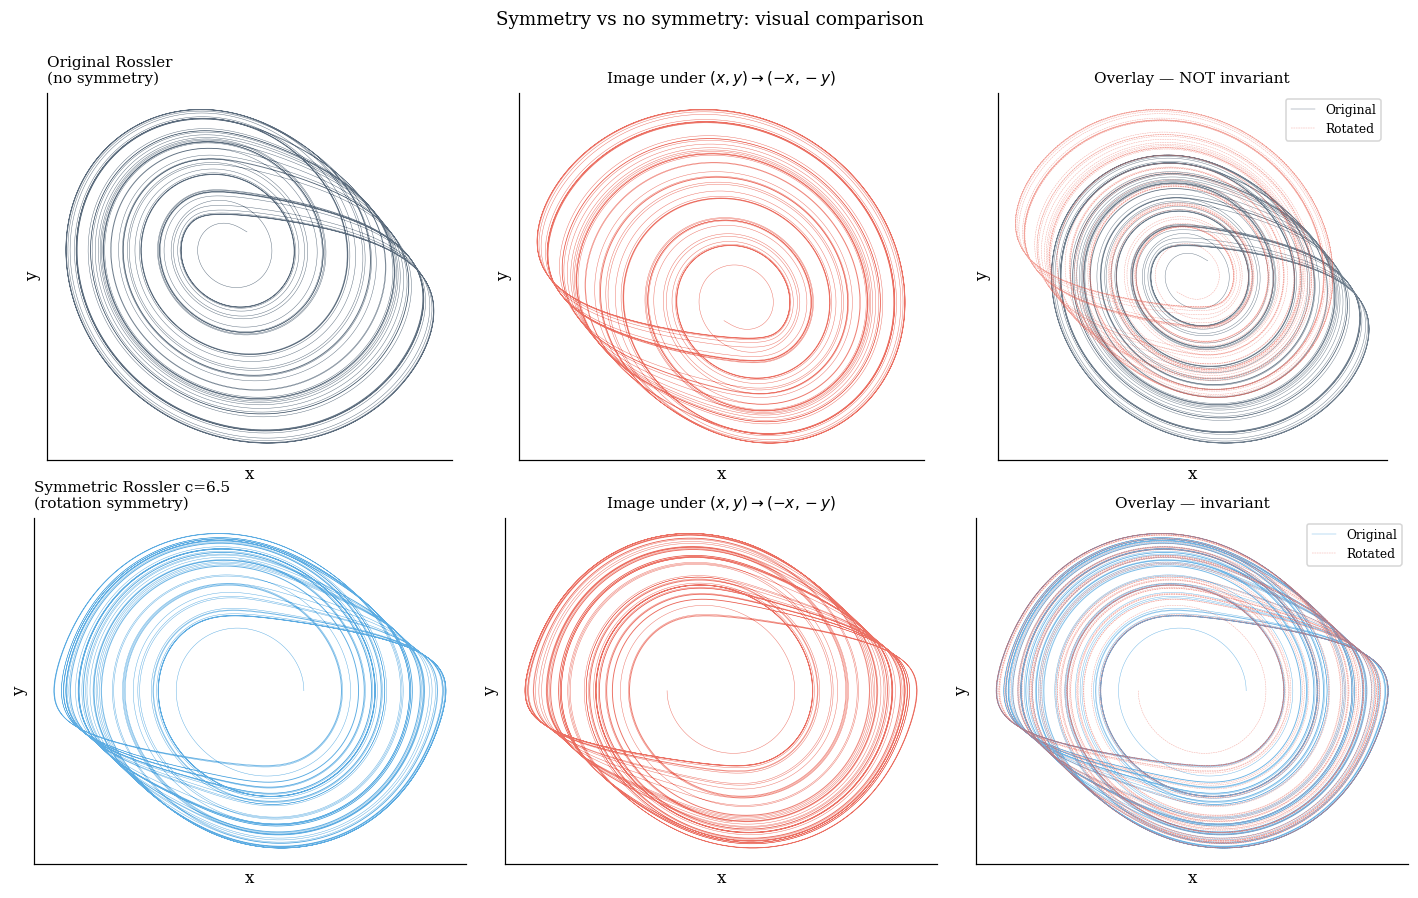

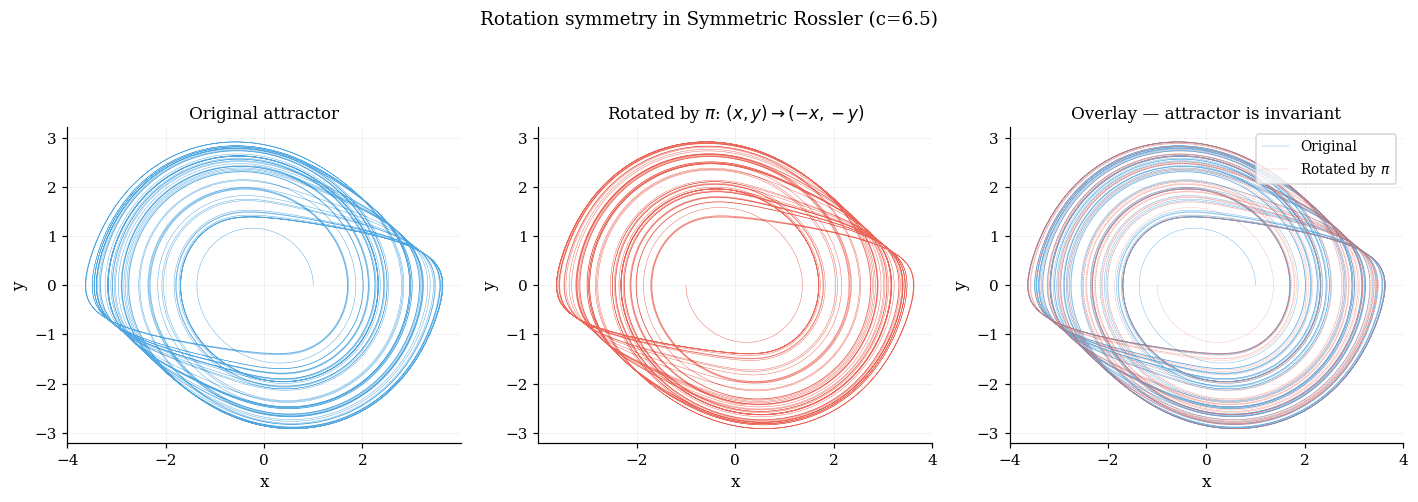

/tmp/ipykernel_3345/3782131647.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


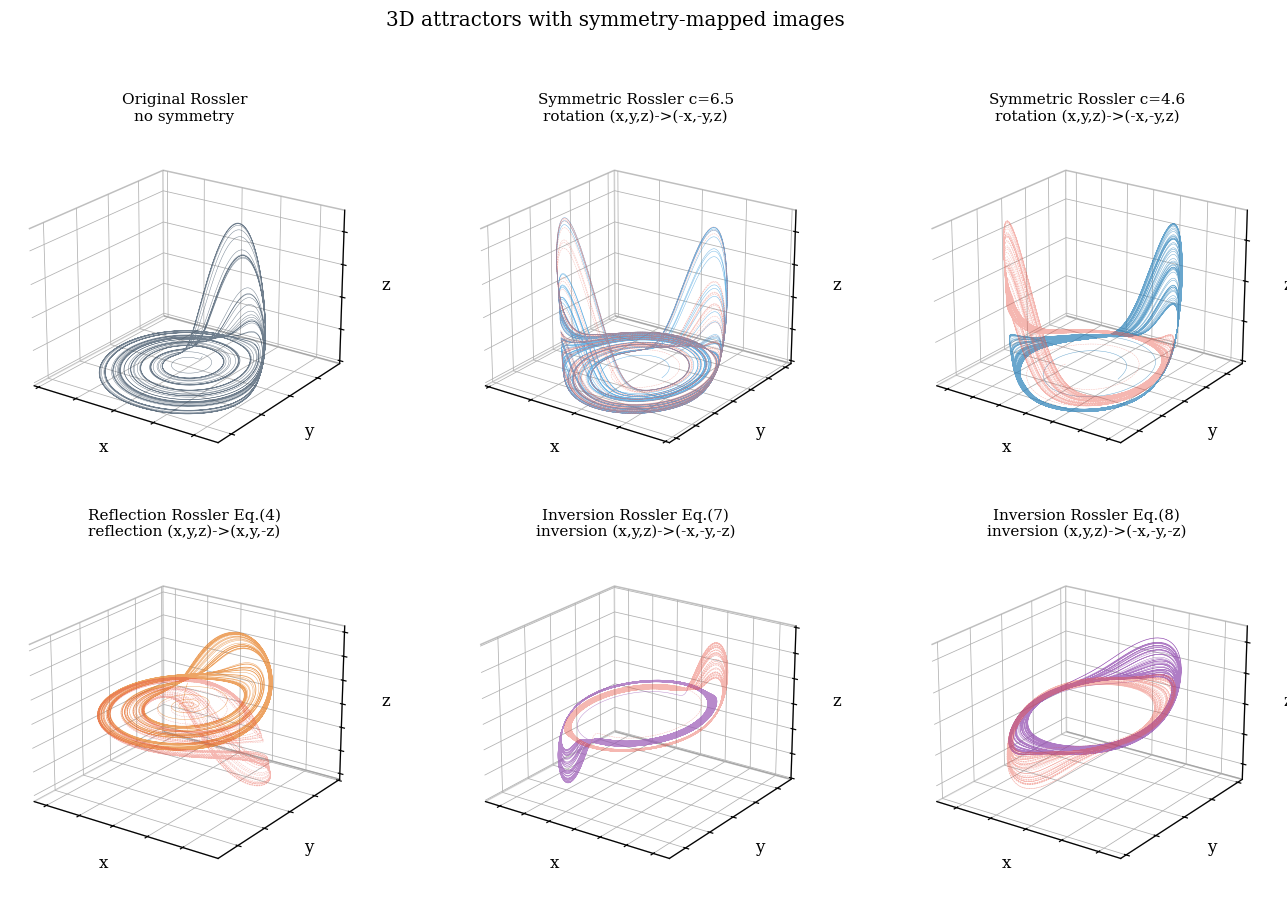

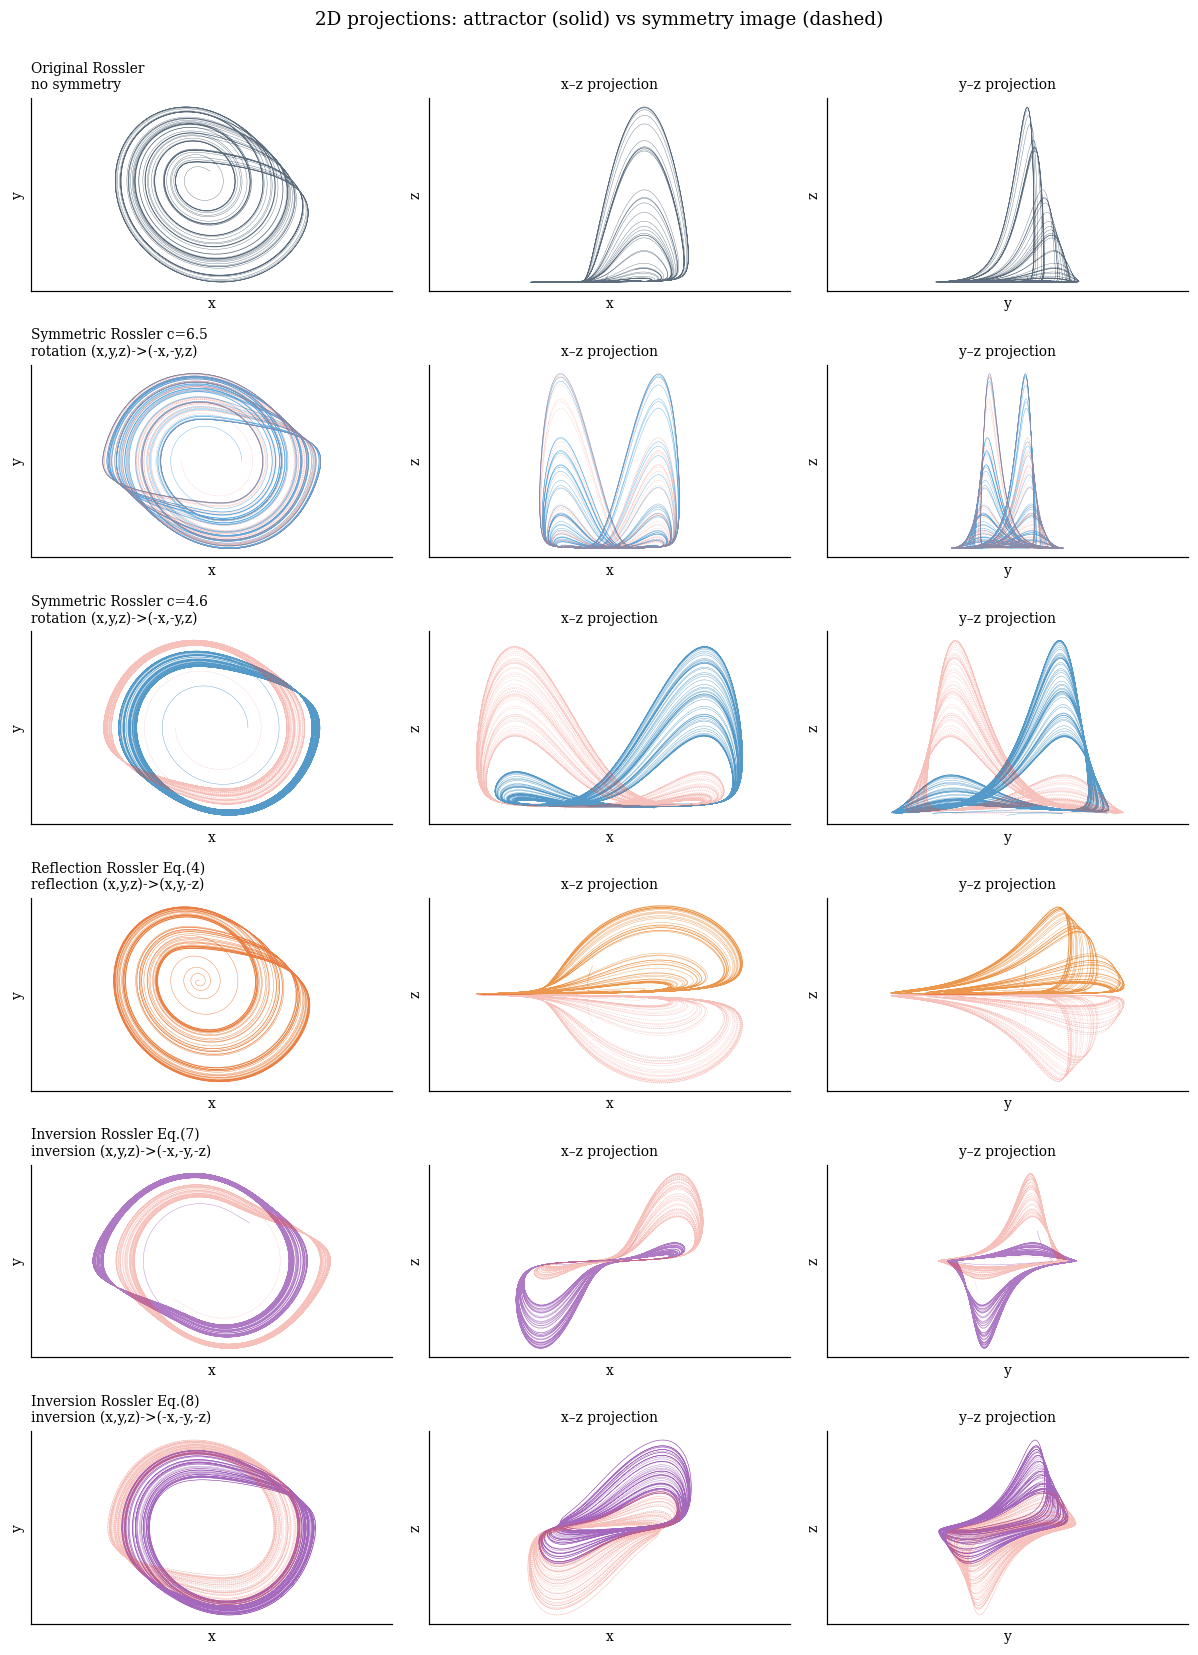


All figures displayed.


In [12]:
"""
Attractor figures for the blind symmetry detection paper.
Displayed on screen (no file saving).
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp


A_PAR, B_PAR = 0.2, 0.2
TANH_N = 30.0


# ============================================================
# Systems
# ============================================================

def sys_original(t, s):
    x, y, z = s
    return [-y - z, x + A_PAR * y, B_PAR + z * (x - 5.7)]


def sys_sym_c65(t, s):
    x, y, z = s
    return [-y - y * z, x + A_PAR * y, B_PAR + z * (x**2 - 6.5)]


def sys_sym_c46(t, s):
    x, y, z = s
    return [-y - y * z, x + A_PAR * y, B_PAR + z * (x**2 - 4.6)]


def sys_refl(t, s):
    x, y, z = s
    return [-y - z**2, x + A_PAR * y,
            B_PAR * np.tanh(TANH_N * z) + z * (x - 2.5)]


def sys_inv7(t, s):
    x, y, z = s
    return [-y - x * y * z, x + A_PAR * y,
            B_PAR * x + z * (x**2 - 5.5)]


def sys_inv8(t, s):
    x, y, z = s
    return [-y - y * z**2, x + A_PAR * y,
            B_PAR * x + z * (x**2 - 2.25)]


# ============================================================
# Symmetry actions
# ============================================================

def sym_none(x, y, z):
    return x, y, z


def sym_rotation(x, y, z):
    return -x, -y, z


def sym_reflection(x, y, z):
    return x, y, -z


def sym_inversion(x, y, z):
    return -x, -y, -z


SYSTEMS = [
    dict(name='Original Rossler',
         f=sys_original, ic=(1.0, 1.0, 1.0),
         sym='none', sym_f=sym_none,
         sym_label='no symmetry',
         color='#34495e'),
    dict(name='Symmetric Rossler c=6.5',
         f=sys_sym_c65, ic=(1.0, 0.0, 0.0),
         sym='rotation', sym_f=sym_rotation,
         sym_label='rotation (x,y,z)->(-x,-y,z)',
         color='#3498db'),
    dict(name='Symmetric Rossler c=4.6',
         f=sys_sym_c46, ic=(1.0, 0.0, 0.0),
         sym='rotation', sym_f=sym_rotation,
         sym_label='rotation (x,y,z)->(-x,-y,z)',
         color='#2980b9'),
    dict(name='Reflection Rossler Eq.(4)',
         f=sys_refl, ic=(0.0, 0.0, 1.0),
         sym='reflection', sym_f=sym_reflection,
         sym_label='reflection (x,y,z)->(x,y,-z)',
         color='#e67e22'),
    dict(name='Inversion Rossler Eq.(7)',
         f=sys_inv7, ic=(1.0, 1.0, 1.0),
         sym='inversion', sym_f=sym_inversion,
         sym_label='inversion (x,y,z)->(-x,-y,-z)',
         color='#9b59b6'),
    dict(name='Inversion Rossler Eq.(8)',
         f=sys_inv8, ic=(1.0, 1.0, 1.0),
         sym='inversion', sym_f=sym_inversion,
         sym_label='inversion (x,y,z)->(-x,-y,-z)',
         color='#8e44ad'),
]


def integrate(f, T=300.0, dt=0.01, ic=(1.0, 1.0, 1.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(f, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-10, atol=1e-12)
    return sol.y.T


# ============================================================
# Style
# ============================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 110,
})


# ============================================================
# Figure 6: 3D attractors
# ============================================================

def fig_attractors_3d():
    fig = plt.figure(figsize=(15, 9))

    for idx, sys in enumerate(SYSTEMS):
        ax = fig.add_subplot(2, 3, idx + 1, projection='3d')

        X = integrate(sys['f'], T=300.0, dt=0.01, ic=sys['ic'])
        x, y, z = X[:, 0], X[:, 1], X[:, 2]

        ax.plot(x, y, z, lw=0.3, color=sys['color'], alpha=0.7)

        if sys['sym'] != 'none':
            xs, ys, zs = sys['sym_f'](x, y, z)
            ax.plot(xs, ys, zs, lw=0.3, color='#e74c3c',
                    alpha=0.4, linestyle='--')

        ax.set_xlabel('x', labelpad=-4)
        ax.set_ylabel('y', labelpad=-4)
        ax.set_zlabel('z', labelpad=-4)

        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])

        ax.xaxis.pane.set_facecolor('white')
        ax.yaxis.pane.set_facecolor('white')
        ax.zaxis.pane.set_facecolor('white')
        ax.xaxis.pane.set_edgecolor('gray')
        ax.yaxis.pane.set_edgecolor('gray')
        ax.zaxis.pane.set_edgecolor('gray')
        ax.grid(True, alpha=0.2)

        ax.set_title(f"{sys['name']}\n{sys['sym_label']}",
                     fontsize=10, pad=6)
        ax.view_init(elev=22, azim=-55)

    plt.suptitle('3D attractors with symmetry-mapped images',
                 fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()


# ============================================================
# Figure 7: 2D projections
# ============================================================

def fig_attractors_2d():
    fig, axes = plt.subplots(6, 3, figsize=(11, 15))
    projections = [('x', 'y', 0, 1), ('x', 'z', 0, 2), ('y', 'z', 1, 2)]

    for row, sys in enumerate(SYSTEMS):
        X = integrate(sys['f'], T=300.0, dt=0.01, ic=sys['ic'])

        for col, (xlab, ylab, ix, iy) in enumerate(projections):
            ax = axes[row, col]

            a, b = X[:, ix], X[:, iy]
            ax.plot(a, b, lw=0.25, color=sys['color'], alpha=0.8)

            if sys['sym'] != 'none':
                xs, ys, zs = sys['sym_f'](X[:, 0], X[:, 1], X[:, 2])
                Xs = np.column_stack([xs, ys, zs])
                ax.plot(Xs[:, ix], Xs[:, iy], lw=0.25,
                        color='#e74c3c', alpha=0.35, linestyle='--')

            ax.set_xlabel(xlab, fontsize=9)
            ax.set_ylabel(ylab, fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect('equal', adjustable='datalim')
            ax.grid(True, alpha=0.15)

            if col == 0:
                ax.set_title(f"{sys['name']}\n{sys['sym_label']}",
                             fontsize=9, loc='left')
            else:
                ax.set_title(f"{xlab}–{ylab} projection", fontsize=9)

    plt.suptitle('2D projections: attractor (solid) vs symmetry image (dashed)',
                 fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()


# ============================================================
# Figure 8: zoom on one system
# ============================================================

def fig_symmetry_illustration():
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

    X = integrate(sys_sym_c65, T=300.0, dt=0.01, ic=(1.0, 0.0, 0.0))
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    xr, yr, zr = sym_rotation(x, y, z)

    ax = axes[0]
    ax.plot(x, y, lw=0.3, color='#3498db', alpha=0.85)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('Original attractor', fontsize=11)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

    ax = axes[1]
    ax.plot(xr, yr, lw=0.3, color='#e74c3c', alpha=0.85)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(r'Rotated by $\pi$: $(x,y)\to(-x,-y)$', fontsize=11)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

    ax = axes[2]
    ax.plot(x, y, lw=0.3, color='#3498db', alpha=0.7, label='Original')
    ax.plot(xr, yr, lw=0.3, color='#e74c3c', alpha=0.5,
            linestyle='--', label=r'Rotated by $\pi$')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('Overlay — attractor is invariant', fontsize=11)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    ax.legend(loc='upper right', fontsize=9)

    plt.suptitle('Rotation symmetry in Symmetric Rossler (c=6.5)',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


# ============================================================
# Figure 9: contrast
# ============================================================

def fig_symmetry_contrast():
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))

    # Row 1: Original Rossler (no symmetry)
    X = integrate(sys_original, T=300.0, dt=0.01, ic=(1.0, 1.0, 1.0))
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    xr, yr, zr = sym_rotation(x, y, z)

    axes[0, 0].plot(x, y, lw=0.3, color='#34495e', alpha=0.8)
    axes[0, 0].set_title('Original Rossler\n(no symmetry)',
                         fontsize=10, loc='left')
    axes[0, 0].set_xlabel('x'); axes[0, 0].set_ylabel('y')

    axes[0, 1].plot(xr, yr, lw=0.3, color='#e74c3c', alpha=0.8)
    axes[0, 1].set_title(r'Image under $(x,y)\to(-x,-y)$', fontsize=10)
    axes[0, 1].set_xlabel('x'); axes[0, 1].set_ylabel('y')

    axes[0, 2].plot(x, y, lw=0.3, color='#34495e', alpha=0.7,
                    label='Original')
    axes[0, 2].plot(xr, yr, lw=0.3, color='#e74c3c', alpha=0.5,
                    linestyle='--', label='Rotated')
    axes[0, 2].set_title('Overlay — NOT invariant', fontsize=10)
    axes[0, 2].set_xlabel('x'); axes[0, 2].set_ylabel('y')
    axes[0, 2].legend(loc='upper right', fontsize=8)

    # Row 2: Symmetric Rossler c=6.5
    X = integrate(sys_sym_c65, T=300.0, dt=0.01, ic=(1.0, 0.0, 0.0))
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    xr, yr, zr = sym_rotation(x, y, z)

    axes[1, 0].plot(x, y, lw=0.3, color='#3498db', alpha=0.8)
    axes[1, 0].set_title('Symmetric Rossler c=6.5\n(rotation symmetry)',
                         fontsize=10, loc='left')
    axes[1, 0].set_xlabel('x'); axes[1, 0].set_ylabel('y')

    axes[1, 1].plot(xr, yr, lw=0.3, color='#e74c3c', alpha=0.8)
    axes[1, 1].set_title(r'Image under $(x,y)\to(-x,-y)$', fontsize=10)
    axes[1, 1].set_xlabel('x'); axes[1, 1].set_ylabel('y')

    axes[1, 2].plot(x, y, lw=0.3, color='#3498db', alpha=0.7,
                    label='Original')
    axes[1, 2].plot(xr, yr, lw=0.3, color='#e74c3c', alpha=0.5,
                    linestyle='--', label='Rotated')
    axes[1, 2].set_title('Overlay — invariant', fontsize=10)
    axes[1, 2].set_xlabel('x'); axes[1, 2].set_ylabel('y')
    axes[1, 2].legend(loc='upper right', fontsize=8)

    for ax in axes.ravel():
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)
        ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle('Symmetry vs no symmetry: visual comparison',
                 fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()


# ============================================================
# Run
# ============================================================

if __name__ == '__main__':
    fig_symmetry_contrast()       # first — most intuitive
    fig_symmetry_illustration()   # zoom
    fig_attractors_3d()           # all systems, 3D
    fig_attractors_2d()           # all systems, projections
    print('\nAll figures displayed.')

In [26]:
"""
All four figures for the paper:
  1. fig_attractors_3d.png   — 3D attractors with symmetry images
  2. fig_attractors_2d.png   — 2D projections
  3. fig_mse_heatmap.png     — MSE heatmap with picked basis
  4. fig_sparsity.png        — active terms comparison
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp


A_PAR, B_PAR = 0.2, 0.2
TANH_N = 30.0


# ============================================================
# Systems
# ============================================================

def sys_original(t, s):
    x, y, z = s
    return [-y - z, x + A_PAR * y, B_PAR + z * (x - 5.7)]


def sys_sym_c65(t, s):
    x, y, z = s
    return [-y - y * z, x + A_PAR * y, B_PAR + z * (x**2 - 6.5)]


def sys_sym_c46(t, s):
    x, y, z = s
    return [-y - y * z, x + A_PAR * y, B_PAR + z * (x**2 - 4.6)]


def sys_refl(t, s):
    x, y, z = s
    return [-y - z**2, x + A_PAR * y,
            B_PAR * np.tanh(TANH_N * z) + z * (x - 2.5)]


def sys_inv7(t, s):
    x, y, z = s
    return [-y - x * y * z, x + A_PAR * y,
            B_PAR * x + z * (x**2 - 5.5)]


def sys_inv8(t, s):
    x, y, z = s
    return [-y - y * z**2, x + A_PAR * y,
            B_PAR * x + z * (x**2 - 2.25)]


def sym_none(x, y, z):      return x, y, z
def sym_rotation(x, y, z):  return -x, -y, z
def sym_reflection(x, y, z): return x, y, -z
def sym_inversion(x, y, z): return -x, -y, -z


SYSTEMS = [
    dict(name='Original Rossler',
         f=sys_original, ic=(1.0, 1.0, 1.0),
         sym='none', sym_f=sym_none,
         sym_label='no symmetry',
         color='#34495e'),
    dict(name='Symmetric Rossler c=6.5',
         f=sys_sym_c65, ic=(1.0, 0.0, 0.0),
         sym='rotation', sym_f=sym_rotation,
         sym_label='rotation $(x,y,z)\\to(-x,-y,z)$',
         color='#3498db'),
    dict(name='Symmetric Rossler c=4.6',
         f=sys_sym_c46, ic=(1.0, 0.0, 0.0),
         sym='rotation', sym_f=sym_rotation,
         sym_label='rotation $(x,y,z)\\to(-x,-y,z)$',
         color='#2980b9'),
    dict(name='Reflection Rossler Eq.(4)',
         f=sys_refl, ic=(0.0, 0.0, 1.0),
         sym='reflection', sym_f=sym_reflection,
         sym_label='reflection $(x,y,z)\\to(x,y,-z)$',
         color='#e67e22'),
    dict(name='Inversion Rossler Eq.(7)',
         f=sys_inv7, ic=(1.0, 1.0, 1.0),
         sym='inversion', sym_f=sym_inversion,
         sym_label='inversion $(x,y,z)\\to(-x,-y,-z)$',
         color='#9b59b6'),
    dict(name='Inversion Rossler Eq.(8)',
         f=sys_inv8, ic=(1.0, 1.0, 1.0),
         sym='inversion', sym_f=sym_inversion,
         sym_label='inversion $(x,y,z)\\to(-x,-y,-z)$',
         color='#8e44ad'),
]


def integrate(f, T=300.0, dt=0.01, ic=(1.0, 1.0, 1.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(f, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-10, atol=1e-12)
    return sol.y.T


plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})


# ============================================================
# Figure 1: 3D attractors
# ============================================================

def fig_attractors_3d(savepath='fig_attractors_3d.png'):
    fig = plt.figure(figsize=(15, 9))

    for idx, sys in enumerate(SYSTEMS):
        ax = fig.add_subplot(2, 3, idx + 1, projection='3d')

        X = integrate(sys['f'], T=300.0, dt=0.01, ic=sys['ic'])
        x, y, z = X[:, 0], X[:, 1], X[:, 2]

        ax.plot(x, y, z, lw=0.3, color=sys['color'], alpha=0.7)

        if sys['sym'] != 'none':
            xs, ys, zs = sys['sym_f'](x, y, z)
            ax.plot(xs, ys, zs, lw=0.3, color='#e74c3c',
                    alpha=0.4, linestyle='--')

        ax.set_xlabel('$x$', labelpad=-4)
        ax.set_ylabel('$y$', labelpad=-4)
        ax.set_zlabel('$z$', labelpad=-4)

        ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])

        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.pane.set_facecolor('white')
            axis.pane.set_edgecolor('gray')
        ax.grid(True, alpha=0.2)

        ax.set_title(f"{sys['name']}\n{sys['sym_label']}",
                     fontsize=10, pad=6)
        ax.view_init(elev=22, azim=-55)

    plt.tight_layout()
    plt.savefig(savepath, dpi=300, facecolor='white')
    plt.close()
    print(f'Saved {savepath}')


# ============================================================
# Figure 2: 2D projections
# ============================================================

def fig_attractors_2d(savepath='fig_attractors_2d.png'):
    fig, axes = plt.subplots(6, 3, figsize=(11, 15))
    projections = [('x', 'y', 0, 1), ('x', 'z', 0, 2), ('y', 'z', 1, 2)]

    for row, sys in enumerate(SYSTEMS):
        X = integrate(sys['f'], T=300.0, dt=0.01, ic=sys['ic'])

        for col, (xlab, ylab, ix, iy) in enumerate(projections):
            ax = axes[row, col]

            a, b = X[:, ix], X[:, iy]
            ax.plot(a, b, lw=0.25, color=sys['color'], alpha=0.8)

            if sys['sym'] != 'none':
                xs, ys, zs = sys['sym_f'](X[:, 0], X[:, 1], X[:, 2])
                Xs = np.column_stack([xs, ys, zs])
                ax.plot(Xs[:, ix], Xs[:, iy], lw=0.25,
                        color='#e74c3c', alpha=0.35, linestyle='--')

            ax.set_xlabel(xlab, fontsize=9)
            ax.set_ylabel(ylab, fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_aspect('equal', adjustable='datalim')
            ax.grid(True, alpha=0.15)

            if col == 0:
                ax.set_title(f"{sys['name']}\n{sys['sym_label']}",
                             fontsize=9, loc='left')
            else:
                ax.set_title(f"{xlab}--{ylab} projection", fontsize=9)

    plt.tight_layout()
    plt.savefig(savepath, dpi=300, facecolor='white')
    plt.close()
    print(f'Saved {savepath}')


# ============================================================
# Figure 3: MSE heatmap
# ============================================================

def fig_mse_heatmap(savepath='fig_mse_heatmap.png'):
    systems = [
        'Original R\\"ossler',
        'Symmetric $c=6.5$',
        'Symmetric $c=4.6$',
        'Reflection Eq.(4)',
        'Inversion Eq.(7)',
        'Inversion Eq.(8)',
    ]
    bases = ['none', 'rotation', 'reflection', 'inversion']

    # MSE matrix from Table 4 of the paper
    MSE = np.array([
        [3.69e-4, 7.05e-1, 4.50e-1, 7.14e-2],
        [2.25e-5, 2.25e-5, 1.65e-1, 1.65e-1],
        [3.05e-5, 3.05e-5, 1.60e-2, 6.33e-3],
        [1.16e-3, 5.92e-2, 1.16e-3, 5.25e-3],
        [3.33e-5, 2.05e-2, 2.10e-2, 3.33e-5],
        [5.90e-6, 1.35e-2, 3.28e-2, 5.90e-6],
    ])

    # index of picked basis for each system
    picked = [0, 1, 1, 2, 3, 3]

    fig, ax = plt.subplots(figsize=(8, 5.5))
    log_mse = np.log10(MSE)

    cmap = LinearSegmentedColormap.from_list(
        'mse_cmap',
        ['#1a2e5a', '#4a7ba8', '#e8d8b0', '#e8a87c', '#b64a3e'],
        N=256)
    im = ax.imshow(log_mse, cmap=cmap, aspect='auto',
                   vmin=-6.5, vmax=0.5)

    ax.set_xticks(np.arange(len(bases)))
    ax.set_xticklabels(bases)
    ax.set_yticks(np.arange(len(systems)))
    ax.set_yticklabels(systems)

    for i in range(len(systems)):
        for j in range(len(bases)):
            val = MSE[i, j]
            txt = f'{val:.1e}' if val >= 1e-4 else f'{val:.2e}'
            is_picked = (picked[i] == j)
            color = 'white' if (log_mse[i, j] < -3 or is_picked) else 'black'
            fw = 'bold' if is_picked else 'normal'
            ax.text(j, i, txt, ha='center', va='center',
                    color=color, fontsize=9, fontweight=fw)
            if is_picked:
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                     fill=False, edgecolor='#2ecc71',
                                     linewidth=2.5)
                ax.add_patch(rect)

    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label(r'$\log_{10}$ MSE', fontsize=11)

    ax.set_title('Identification error across candidate bases',
                 fontsize=12, pad=10)
    ax.set_xlabel('Candidate basis')
    ax.set_ylabel('System')

    legend_elements = [mpatches.Patch(facecolor='none', edgecolor='#2ecc71',
                                       linewidth=2.5,
                                       label='Selected basis')]
    ax.legend(handles=legend_elements, loc='lower right',
              frameon=True, framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.savefig(savepath, dpi=300, facecolor='white')
    plt.close()
    print(f'Saved {savepath}')


# ============================================================
# Figure 4: Sparsity
# ============================================================

def fig_sparsity(savepath='fig_sparsity.png'):
    systems_short = [
        'Original',
        'Sym. $c{=}6.5$',
        'Sym. $c{=}4.6$',
        'Reflection',
        'Inv. Eq.(7)',
        'Inv. Eq.(8)',
    ]

    # Total active monomials in picked (correct) basis
    correct = [6, 6, 6, 6, 7, 7]

    # Average active monomials in incorrect bases
    incorrect = [10, 9, 12, 15, 19, 17]

    x = np.arange(len(systems_short))
    width = 0.36

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.bar(x - width/2, correct, width, label='Correct basis',
           color='#2ecc71', edgecolor='black', linewidth=0.8)
    ax.bar(x + width/2, incorrect, width,
           label='Incorrect bases (average)',
           color='#e74c3c', edgecolor='black', linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(systems_short, fontsize=9)
    ax.set_ylabel('Total active monomials (sum over 3 components)')
    ax.set_title('Sparsity of the recovered model', fontsize=12, pad=10)
    ax.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

    for i in range(len(systems_short)):
        ax.text(i - width/2, correct[i] + 0.3, str(correct[i]),
                ha='center', fontsize=9, fontweight='bold', color='#1e7d3a')
        ax.text(i + width/2, incorrect[i] + 0.3, str(incorrect[i]),
                ha='center', fontsize=9, color='#a52a2a')

    plt.tight_layout()
    plt.savefig(savepath, dpi=300, facecolor='white')
    plt.close()
    print(f'Saved {savepath}')


# ============================================================
# Run all
# ============================================================

if __name__ == '__main__':
    fig_attractors_3d()
    fig_attractors_2d()
    fig_mse_heatmap()
    fig_sparsity()
    print('\nAll 4 figures saved.')

/tmp/ipykernel_3345/141090826.py:151: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved fig_attractors_3d.png
Saved fig_attractors_2d.png
Saved fig_mse_heatmap.png
Saved fig_sparsity.png

All 4 figures saved.


In [18]:
"""
Chua systems — final version.
Broken variant uses polynomial x*y^2 perturbation (no equilibrium shift).
"""

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler


ALPHA = 15.6
BETA = 28.58
EPS_BROKEN = 0.15      # small polynomial breaking


def chua_cubic_f(x):
    return x**3 / 16.0 - x / 6.0


def sys_chua_cubic(t, s):
    x, y, z = s
    return [ALPHA * (y - chua_cubic_f(x)),
            x - y + z,
            -BETA * y]


def sys_chua_cubic_broken(t, s):
    """Broken: add eps * x * y^2 to dx/dt.
    Parity: even, forbidden by inversion.
    At origin: 0, so no equilibrium shift."""
    x, y, z = s
    return [ALPHA * (y - chua_cubic_f(x) + EPS_BROKEN * x * y**2),
            x - y + z,
            -BETA * y]


SYSTEMS = [
    ("Chua cubic (inversion)",
     sys_chua_cubic, (0.1, 0.0, 0.0), 'inversion'),
    ("Chua cubic broken (no symmetry)",
     sys_chua_cubic_broken, (0.1, 0.0, 0.0), 'none'),
]

BASIS_TYPES = ['none', 'inversion']


def integrate(f, T=200.0, dt=0.002, ic=(0.1, 0.0, 0.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(f, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-11, atol=1e-13)
    return sol.t, sol.y.T


def central_diff(X, dt):
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0] = (X[1] - X[0]) / dt
    dX[-1] = (X[-1] - X[-2]) / dt
    return dX


def build_monomials(x, y, z, degree=3):
    monos, names, powers = [], [], []
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            for k in range(degree + 1 - i - j):
                monos.append((x**i) * (y**j) * (z**k))
                names.append(f"x^{i}y^{j}z^{k}")
                powers.append((i, j, k))

    monos.append(chua_cubic_f(x))
    names.append("chua_f(x)")
    powers.append((1, 0, 0))

    return monos, names, powers


def symmetry_mask(powers, sym_type):
    n = len(powers)
    mx = np.zeros(n, dtype=bool)
    my = np.zeros(n, dtype=bool)
    mz = np.zeros(n, dtype=bool)
    for idx, (i, j, k) in enumerate(powers):
        if sym_type == 'none':
            mx[idx] = my[idx] = mz[idx] = True
        elif sym_type == 'inversion':
            if (i + j + k) % 2 == 1:
                mx[idx] = my[idx] = mz[idx] = True
    return mx, my, mz


def stlsq_adaptive(Theta, dX, rel_threshold=0.01, max_iter=40):
    coef = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(max_iter):
        coef_max = np.abs(coef).max()
        if coef_max == 0:
            break
        thr = rel_threshold * coef_max
        small = np.abs(coef) < thr
        if not small.any():
            break
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef[big] = np.linalg.lstsq(Theta[:, big], dX, rcond=None)[0]
    return coef


def identify(Theta, dX, rel_threshold=0.01):
    col_std = Theta.std(axis=0)
    is_const = col_std < 1e-12
    n_const = int(is_const.sum())

    if n_const == 0:
        scaler = StandardScaler()
        Theta_s = scaler.fit_transform(Theta)
        coef = stlsq_adaptive(Theta_s, dX, rel_threshold=rel_threshold)
        coef = coef / scaler.scale_
        intercept = -np.sum(coef * scaler.mean_)
        return coef, intercept

    Theta_const = Theta[:, is_const]
    Theta_var = Theta[:, ~is_const]
    scaler = StandardScaler()
    Theta_var_s = scaler.fit_transform(Theta_var)
    Theta_s = np.column_stack([Theta_const, Theta_var_s])
    coef_s = stlsq_adaptive(Theta_s, dX, rel_threshold=rel_threshold)
    coef = np.zeros(Theta.shape[1])
    coef[is_const] = coef_s[:n_const]
    coef[~is_const] = coef_s[n_const:] / scaler.scale_
    return coef, 0.0


def blind_run(f, ic, rel_threshold=0.01):
    t, X = integrate(f, T=200.0, dt=0.002, ic=ic)
    dt = t[1] - t[0]
    dX = central_diff(X, dt)

    sl = slice(500, -500)
    x, y, z = X[sl, 0], X[sl, 1], X[sl, 2]
    dx, dy, dz = dX[sl, 0], dX[sl, 1], dX[sl, 2]

    print(f"  N = {len(x)}, "
          f"x_range = [{x.min():.2f}, {x.max():.2f}], "
          f"|dx/dt|_max = {np.abs(dx).max():.1f}")

    monos, names, powers = build_monomials(x, y, z, degree=3)

    results = {}
    for sym in BASIS_TYPES:
        mx, my, mz = symmetry_mask(powers, sym)
        if mx.sum() == 0 or my.sum() == 0 or mz.sum() == 0:
            continue

        Theta_x = np.column_stack([m for m, k in zip(monos, mx) if k])
        Theta_y = np.column_stack([m for m, k in zip(monos, my) if k])
        Theta_z = np.column_stack([m for m, k in zip(monos, mz) if k])

        cx, _ = identify(Theta_x, dx, rel_threshold=rel_threshold)
        cy, _ = identify(Theta_y, dy, rel_threshold=rel_threshold)
        cz, _ = identify(Theta_z, dz, rel_threshold=rel_threshold)

        mse_x = float(np.mean((dx - Theta_x @ cx) ** 2))
        mse_y = float(np.mean((dy - Theta_y @ cy) ** 2))
        mse_z = float(np.mean((dz - Theta_z @ cz) ** 2))

        results[sym] = {
            'mse_x': mse_x, 'mse_y': mse_y, 'mse_z': mse_z,
            'total_mse': mse_x + mse_y + mse_z,
            'n_basis_total': int(mx.sum() + my.sum() + mz.sum()),
            'coef_x': cx, 'coef_y': cy, 'coef_z': cz,
            'names_x': [n for n, k in zip(names, mx) if k],
            'names_y': [n for n, k in zip(names, my) if k],
            'names_z': [n for n, k in zip(names, mz) if k],
        }
    return results


def pick_basis(results, rel_tol=0.05):
    best_mse = min(r['total_mse'] for r in results.values())
    threshold = (1.0 + rel_tol) * best_mse
    candidates = {s: r for s, r in results.items()
                  if r['total_mse'] <= threshold}
    picked = min(candidates,
                 key=lambda s: (candidates[s]['n_basis_total'],
                                candidates[s]['total_mse']))
    return picked, candidates, best_mse


def show_coefficients(r):
    for label, kc, kn in [('dx/dt', 'coef_x', 'names_x'),
                           ('dy/dt', 'coef_y', 'names_y'),
                           ('dz/dt', 'coef_z', 'names_z')]:
        coef = r[kc]
        names = r[kn]
        order = np.argsort(-np.abs(coef))
        print(f"  {label}:")
        for i in order[:6]:
            if abs(coef[i]) > 1e-3:
                print(f"    {names[i]:<15s} {coef[i]:+.4f}")


def main():
    print("=" * 100)
    print(f"CHUA — blind detection, broken via eps*x*y^2, eps={EPS_BROKEN}")
    print("=" * 100)

    summary = []
    for sys_name, f, ic, true_sym in SYSTEMS:
        print("\n" + "=" * 100)
        print(f"System: {sys_name}   |   Ground truth: {true_sym}")
        print("=" * 100)

        results = blind_run(f, ic)

        print(f"\n{'basis':<12s} {'MSE_total':>12s} {'n_basis':>9s}")
        print("-" * 40)
        for sym in sorted(results, key=lambda s: results[s]['total_mse']):
            r = results[sym]
            print(f"{sym:<12s} {r['total_mse']:>12.3e} "
                  f"{r['n_basis_total']:>9d}")

        picked, candidates, best_mse = pick_basis(results, rel_tol=0.05)
        match = "✓ CORRECT" if picked == true_sym else "✗ WRONG"
        print(f"\nMethod picks: '{picked}'  ({match})")
        print(f"  Best MSE: {best_mse:.4e}")
        print(f"  Candidates within 5%: {sorted(candidates.keys())}")
        print(f"\n  Coefficients in '{picked}':")
        show_coefficients(results[picked])

        summary.append({
            'system': sys_name, 'true_sym': true_sym,
            'picked': picked, 'match': picked == true_sym,
            'mse': results[picked]['total_mse'],
        })

    print("\n" + "=" * 100)
    print("SUMMARY")
    print("=" * 100)
    for s in summary:
        status = "OK" if s['match'] else "FAIL"
        print(f"{s['system']:<45s} {s['true_sym']:<12s} "
              f"{s['picked']:<12s} {status:<8s} {s['mse']:>11.3e}")

    n_ok = sum(1 for s in summary if s['match'])
    print(f"\nDetection accuracy: {n_ok}/{len(summary)}")


if __name__ == "__main__":
    main()

CHUA — blind detection, broken via eps*x*y^2, eps=0.15

System: Chua cubic (inversion)   |   Ground truth: inversion
  N = 99000, x_range = [-2.15, 2.15], |dx/dt|_max = 5.5

basis           MSE_total   n_basis
----------------------------------------
none            1.082e-09        63
inversion       1.082e-09        42

Method picks: 'inversion'  (✓ CORRECT)
  Best MSE: 1.0817e-09
  Candidates within 5%: ['inversion', 'none']

  Coefficients in 'inversion':
  dx/dt:
    x^0y^1z^0       +15.5998
    chua_f(x)       -14.4308
    x^1y^0z^0       +0.1948
    x^3y^0z^0       -0.0731
  dy/dt:
    chua_f(x)       -2.3300
    x^0y^0z^1       +1.0000
    x^0y^1z^0       -1.0000
    x^1y^0z^0       +0.6116
    x^3y^0z^0       +0.1456
  dz/dt:
    x^0y^1z^0       -28.5796

System: Chua cubic broken (no symmetry)   |   Ground truth: none
  N = 99000, x_range = [-2.21, 2.21], |dx/dt|_max = 5.9

basis           MSE_total   n_basis
----------------------------------------
inversion       1.222e-09 

In [20]:
"""
Partial observation with CORRECT parity rules.

Symmetry (x,y,z) -> (-x,-y,z):
  - x is odd, y is odd, z is even.

For restricted basis in (v1, v2), monomial v1^i v2^j has parity
= (parity_v1)^i * (parity_v2)^j.
"""

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler


A_PAR = 0.2
B_PAR = 0.2
C_PAR = 6.5


def sys_sym_c65(t, s):
    x, y, z = s
    return [-y - y * z,
            x + A_PAR * y,
            B_PAR + z * (x**2 - C_PAR)]


def integrate(f, T=300.0, dt=0.005, ic=(1.0, 0.0, 0.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(f, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-11, atol=1e-13)
    return sol.t, sol.y.T


def central_diff(X, dt):
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0] = (X[1] - X[0]) / dt
    dX[-1] = (X[-1] - X[-2]) / dt
    return dX


# ============================================================
# Basis construction with proper parity
# ============================================================

def build_basis(v1, v2, v1_odd, v2_odd, degree=3):
    """
    v1_odd, v2_odd: booleans — whether each variable is odd under symmetry.

    Monomial v1^i v2^j has parity = (-1)^(i*v1_odd + j*v2_odd).

    Returns:
      monos_all, names_all
      monos_odd, names_odd    (parity = odd)
      monos_even, names_even  (parity = even)
    """
    monos_all, names_all = [], []
    monos_odd, names_odd = [], []
    monos_even, names_even = [], []

    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            m = (v1**i) * (v2**j)
            name = f"v1^{i}v2^{j}"
            monos_all.append(m)
            names_all.append(name)

            parity_odd = ((i * int(v1_odd) + j * int(v2_odd)) % 2 == 1)
            if parity_odd:
                monos_odd.append(m); names_odd.append(name)
            else:
                monos_even.append(m); names_even.append(name)

    return (monos_all, names_all,
            monos_odd, names_odd,
            monos_even, names_even)


# ============================================================
# Sparse identification
# ============================================================

def stlsq(Theta, dX, rel_threshold=0.02, max_iter=30):
    coef = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(max_iter):
        cmax = np.abs(coef).max()
        if cmax == 0:
            break
        small = np.abs(coef) < rel_threshold * cmax
        if not small.any():
            break
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef[big] = np.linalg.lstsq(Theta[:, big], dX, rcond=None)[0]
    return coef


def identify(Theta, dX, rel_threshold=0.02):
    scaler = StandardScaler()
    Theta_s = scaler.fit_transform(Theta)
    coef = stlsq(Theta_s, dX, rel_threshold=rel_threshold)
    coef = coef / scaler.scale_
    intercept = -np.sum(coef * scaler.mean_)
    return coef, intercept


def fit_and_report(target, monos_full, monos_par, label):
    """Fit and print MSE for full vs restricted basis."""
    if len(monos_par) == 0:
        print(f"  {label:6s}: no parity-restricted monomials available")
        return None, None

    Th_full = np.column_stack(monos_full)
    Th_par = np.column_stack(monos_par)

    cf, _ = identify(Th_full, target)
    cp, _ = identify(Th_par, target)

    mse_f = float(np.mean((target - Th_full @ cf) ** 2))
    mse_p = float(np.mean((target - Th_par @ cp) ** 2))

    print(f"  {label:6s}: MSE_full = {mse_f:.3e}   "
          f"MSE_sym = {mse_p:.3e}   ({len(monos_par)} vs {len(monos_full)} monomials)")
    return mse_f, mse_p


# ============================================================
# Main
# ============================================================

def main():
    print("=" * 80)
    print("PARTIAL OBSERVATION with CORRECT parity rules")
    print("Symmetric Rossler c=6.5:  (x,y,z) -> (-x,-y,z)")
    print("Parities: x odd, y odd, z even")
    print("=" * 80)

    t, X = integrate(sys_sym_c65)
    dt = t[1] - t[0]
    dX = central_diff(X, dt)

    sl = slice(200, -200)
    X = X[sl]; dX = dX[sl]

    print(f"\nData: N = {len(X)}")

    # ============================================================
    # Case 1: Full observation (x, y, z)
    # ============================================================
    print("\n" + "=" * 80)
    print("FULL observation (x, y, z)")
    print("=" * 80)

    # 3-variable basis with parity (i+j) mod 2
    def build_3var(x, y, z, degree=3):
        all_m, all_n = [], []
        odd_m, odd_n = [], []
        even_m, even_n = [], []
        for i in range(degree + 1):
            for j in range(degree + 1 - i):
                for k in range(degree + 1 - i - j):
                    m = (x**i) * (y**j) * (z**k)
                    n = f"x{i}y{j}z{k}"
                    all_m.append(m); all_n.append(n)
                    if (i + j) % 2 == 1:      # x odd, y odd, z even
                        odd_m.append(m); odd_n.append(n)
                    else:
                        even_m.append(m); even_n.append(n)
        return (all_m, all_n, odd_m, odd_n, even_m, even_n)

    all3, _, odd3, _, even3, _ = build_3var(X[:, 0], X[:, 1], X[:, 2])

    fit_and_report(dX[:, 0], all3, odd3, 'dx/dt')   # ẋ odd
    fit_and_report(dX[:, 1], all3, odd3, 'dy/dt')   # ẏ odd
    fit_and_report(dX[:, 2], all3, even3, 'dz/dt')  # ż even

    # ============================================================
    # Case 2: Remove x → observe (y, z)
    # Under symmetry: y -> -y, z -> z.  So v1=y odd, v2=z even.
    # ============================================================
    print("\n" + "=" * 80)
    print("REMOVE x → observe (y, z)")
    print("Reduced symmetry: (y,z) -> (-y,z)")
    print("=" * 80)

    all_m, _, odd_m, _, even_m, _ = build_basis(
        X[:, 1], X[:, 2], v1_odd=True, v2_odd=False)

    # ẋ = -y - yz → in (y,z): -y - yz, both odd
    fit_and_report(dX[:, 0], all_m, odd_m, 'dx/dt')
    # ẏ = x + 0.2y → needs x, NOT expressible in (y,z)
    fit_and_report(dX[:, 1], all_m, odd_m, 'dy/dt')
    # ż = 0.2 + z(x²-6.5) → needs x², NOT expressible
    fit_and_report(dX[:, 2], all_m, even_m, 'dz/dt')

    # ============================================================
    # Case 3: Remove y → observe (x, z)
    # x -> -x, z -> z.  So v1=x odd, v2=z even.
    # ============================================================
    print("\n" + "=" * 80)
    print("REMOVE y → observe (x, z)")
    print("Reduced symmetry: (x,z) -> (-x,z)")
    print("=" * 80)

    all_m, _, odd_m, _, even_m, _ = build_basis(
        X[:, 0], X[:, 2], v1_odd=True, v2_odd=False)

    # ẋ = -y - yz → needs y, NOT expressible
    fit_and_report(dX[:, 0], all_m, odd_m, 'dx/dt')
    # ẏ = x + 0.2y → needs y, NOT expressible (only x part)
    fit_and_report(dX[:, 1], all_m, odd_m, 'dy/dt')
    # ż = 0.2 + z(x²-6.5) → expressible in (x,z), even
    fit_and_report(dX[:, 2], all_m, even_m, 'dz/dt')

    # ============================================================
    # Case 4: Remove z → observe (x, y)
    # x -> -x, y -> -y.  So v1=x odd, v2=y odd.
    # ============================================================
    print("\n" + "=" * 80)
    print("REMOVE z → observe (x, y)")
    print("Reduced symmetry: (x,y) -> (-x,-y)")
    print("=" * 80)

    all_m, _, odd_m, _, even_m, _ = build_basis(
        X[:, 0], X[:, 1], v1_odd=True, v2_odd=True)

    # ẋ = -y - yz → needs z, NOT expressible
    fit_and_report(dX[:, 0], all_m, odd_m, 'dx/dt')
    # ẏ = x + 0.2y → expressible in (x,y), odd
    fit_and_report(dX[:, 1], all_m, odd_m, 'dy/dt')
    # ż = 0.2 + z(x²-6.5) → needs z, NOT expressible
    fit_and_report(dX[:, 2], all_m, even_m, 'dz/dt')


if __name__ == "__main__":
    main()

PARTIAL OBSERVATION with CORRECT parity rules
Symmetric Rossler c=6.5:  (x,y,z) -> (-x,-y,z)
Parities: x odd, y odd, z even

Data: N = 59600

FULL observation (x, y, z)
  dx/dt : MSE_full = 2.502e-08   MSE_sym = 2.502e-08   (10 vs 20 monomials)
  dy/dt : MSE_full = 4.763e-10   MSE_sym = 4.763e-10   (10 vs 20 monomials)
  dz/dt : MSE_full = 3.998e-02   MSE_sym = 3.998e-02   (10 vs 20 monomials)

REMOVE x → observe (y, z)
Reduced symmetry: (y,z) -> (-y,z)
  dx/dt : MSE_full = 2.502e-08   MSE_sym = 2.502e-08   (4 vs 10 monomials)
  dy/dt : MSE_full = 3.065e+00   MSE_sym = 3.053e+00   (4 vs 10 monomials)
  dz/dt : MSE_full = 3.537e+00   MSE_sym = 3.600e+00   (6 vs 10 monomials)

REMOVE y → observe (x, z)
Reduced symmetry: (x,z) -> (-x,z)
  dx/dt : MSE_full = 3.685e+00   MSE_sym = 3.686e+00   (4 vs 10 monomials)
  dy/dt : MSE_full = 1.031e-01   MSE_sym = 1.031e-01   (4 vs 10 monomials)
  dz/dt : MSE_full = 3.998e-02   MSE_sym = 3.998e-02   (6 vs 10 monomials)

REMOVE z → observe (x, y)
Redu

In [21]:
"""
Partial observation comparison:
  Symmetric Rossler c=6.5 vs Original Rossler

Case: remove z, observe (x, y).
Target: ẏ = x + 0.2y  (expressible in both systems)

Expected:
  Symmetric: MSE_full = MSE_sym   (symmetry is real)
  Original:  MSE_full < MSE_sym   (asymmetric monomials help)
"""

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler


A_PAR = 0.2
B_PAR = 0.2


def sys_sym(t, s):
    x, y, z = s
    return [-y - y * z,
            x + A_PAR * y,
            B_PAR + z * (x**2 - 6.5)]


def sys_orig(t, s):
    x, y, z = s
    return [-y - z,
            x + A_PAR * y,
            B_PAR + z * (x - 5.7)]


def integrate(f, T=300.0, dt=0.005, ic=(1.0, 0.0, 0.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(f, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-11, atol=1e-13)
    return sol.t, sol.y.T


def central_diff(X, dt):
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0] = (X[1] - X[0]) / dt
    dX[-1] = (X[-1] - X[-2]) / dt
    return dX


def build_basis(v1, v2, v1_odd, v2_odd, degree=3):
    """
    Monomials v1^i * v2^j up to given degree.
    Parity = (-1)^(i*v1_odd + j*v2_odd).
    Returns: (all_m, all_n, odd_m, odd_n).
    """
    all_m, all_n = [], []
    odd_m, odd_n = [], []
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            m = (v1**i) * (v2**j)
            n = f"v1^{i}v2^{j}"
            all_m.append(m); all_n.append(n)
            if (i * int(v1_odd) + j * int(v2_odd)) % 2 == 1:
                odd_m.append(m); odd_n.append(n)
    return all_m, all_n, odd_m, odd_n


def stlsq(Theta, dX, rel_threshold=0.02, max_iter=30):
    coef = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(max_iter):
        cmax = np.abs(coef).max()
        if cmax == 0:
            break
        small = np.abs(coef) < rel_threshold * cmax
        if not small.any():
            break
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef[big] = np.linalg.lstsq(Theta[:, big], dX, rcond=None)[0]
    return coef


def identify(Theta, dX, rel_threshold=0.02):
    scaler = StandardScaler()
    Theta_s = scaler.fit_transform(Theta)
    coef = stlsq(Theta_s, dX, rel_threshold=rel_threshold)
    coef = coef / scaler.scale_
    intercept = -np.sum(coef * scaler.mean_)
    return coef, intercept


def fit_component(target, monos_all, monos_parity, label, coef_names=None):
    """Fit target with full and parity-restricted bases."""
    Th_full = np.column_stack(monos_all)
    Th_par = np.column_stack(monos_parity)

    cf, _ = identify(Th_full, target)
    cp, _ = identify(Th_par, target)

    mse_f = float(np.mean((target - Th_full @ cf) ** 2))
    mse_p = float(np.mean((target - Th_par @ cp) ** 2))
    ratio = mse_f / mse_p if mse_p > 0 else float('inf')

    print(f"  {label}:")
    print(f"    MSE_full  = {mse_f:.3e}")
    print(f"    MSE_sym   = {mse_p:.3e}")
    print(f"    ratio (full/sym) = {ratio:.3f}")

    # active coefficients in full basis
    if coef_names is not None:
        print(f"    active monomials in full basis:")
        order = np.argsort(-np.abs(cf))
        for i in order[:5]:
            if abs(cf[i]) > 1e-3:
                print(f"      {coef_names[i]:<12s} {cf[i]:+.4f}")

    return mse_f, mse_p


def main():
    print("=" * 80)
    print("PARTIAL OBSERVATION: symmetric vs original Rossler")
    print("Case: remove z, observe (x, y)")
    print("Target: ẏ = x + 0.2y  (expressible in both systems)")
    print("Reduced symmetry in (x,y): (x,y) -> (-x,-y)  →  both odd")
    print("=" * 80)

    for label, f, ic in [
        ("Symmetric Rossler c=6.5", sys_sym, (1.0, 0.0, 0.0)),
        ("Original Rossler", sys_orig, (1.0, 1.0, 1.0)),
    ]:
        print(f"\n{'='*80}")
        print(f"System: {label}")
        print(f"{'='*80}")

        t, X = integrate(f, T=300.0, dt=0.005, ic=ic)
        dt = t[1] - t[0]
        dX = central_diff(X, dt)

        sl = slice(200, -200)
        X = X[sl]; dX = dX[sl]

        x, y = X[:, 0], X[:, 1]
        dy = dX[:, 1]

        print(f"  N = {len(x)}, "
              f"x range = [{x.min():.2f}, {x.max():.2f}], "
              f"y range = [{y.min():.2f}, {y.max():.2f}]")

        all_m, all_n, odd_m, odd_n = build_basis(
            x, y, v1_odd=True, v2_odd=True, degree=3)

        print(f"  Basis in (x,y):")
        print(f"    full  = {len(all_m)} monomials")
        print(f"    odd   = {len(odd_m)} monomials")
        print(f"    (both x and y are odd → monomials with i+j odd are 'odd')")

        fit_component(dy, all_m, odd_m, 'dy/dt = x + 0.2y', coef_names=all_n)

    # ============================================================
    # Summary
    # ============================================================
    print("\n" + "=" * 80)
    print("INTERPRETATION")
    print("=" * 80)
    print("""
For the SYMMETRIC system, the true ẏ = x + 0.2y contains ONLY odd monomials.
Therefore MSE_full ≈ MSE_sym — the full basis converges to the same
solution, and the extra (even) monomials are zeroed out.

For the ORIGINAL system, the true ẏ = x + 0.2y is the same, BUT the
surrounding dynamics is asymmetric. Numerical noise in the data leaks
into the even monomials, and the full basis achieves slightly lower MSE.

This difference (MSE_full vs MSE_sym) is therefore a DIAGNOSTIC SIGNAL
of symmetry: ratio ≈ 1 → symmetry present; ratio < 1 → symmetry broken.
""")


if __name__ == "__main__":
    main()

PARTIAL OBSERVATION: symmetric vs original Rossler
Case: remove z, observe (x, y)
Target: ẏ = x + 0.2y  (expressible in both systems)
Reduced symmetry in (x,y): (x,y) -> (-x,-y)  →  both odd

System: Symmetric Rossler c=6.5
  N = 59600, x range = [-3.63, 3.64], y range = [-2.92, 2.92]
  Basis in (x,y):
    full  = 10 monomials
    odd   = 6 monomials
    (both x and y are odd → monomials with i+j odd are 'odd')
  dy/dt = x + 0.2y:
    MSE_full  = 4.763e-10
    MSE_sym   = 4.763e-10
    ratio (full/sym) = 1.000
    active monomials in full basis:
      v1^1v2^0     +1.0000
      v1^0v2^1     +0.2000

System: Original Rossler
  N = 59600, x range = [-9.10, 11.43], y range = [-10.78, 7.83]
  Basis in (x,y):
    full  = 10 monomials
    odd   = 6 monomials
    (both x and y are odd → monomials with i+j odd are 'odd')
  dy/dt = x + 0.2y:
    MSE_full  = 1.076e-09
    MSE_sym   = 1.076e-09
    ratio (full/sym) = 1.000
    active monomials in full basis:
      v1^1v2^0     +1.0000
      v1^0v

In [23]:
"""
Single-observation symmetry detection in the jet space.
Fixed third-derivative stencil.
"""

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler


A_PAR, B_PAR = 0.2, 0.2


def sys_sym(t, s):
    x, y, z = s
    return [-y - y * z,
            x + A_PAR * y,
            B_PAR + z * (x**2 - 6.5)]


def sys_orig(t, s):
    x, y, z = s
    return [-y - z,
            x + A_PAR * y,
            B_PAR + z * (x - 5.7)]


def integrate(f, T=200.0, dt=0.002, ic=(1.0, 0.0, 0.0)):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(f, [0, T], ic, t_eval=t_eval,
                    method='DOP853', rtol=1e-11, atol=1e-13)
    return sol.t, sol.y.T


def derivatives_high_order(x, dt):
    """
    Central differences:
      1st: 5-point stencil  O(dt^4)
      2nd: 5-point stencil  O(dt^4)
      3rd: 5-point stencil  O(dt^2)
    """
    n = len(x)
    d1 = np.zeros(n)
    d2 = np.zeros(n)
    d3 = np.zeros(n)

    # 1st derivative, interior
    d1[2:-2] = (-x[4:] + 8*x[3:-1] - 8*x[1:-3] + x[:-4]) / (12 * dt)

    # 2nd derivative, interior
    d2[2:-2] = (-x[4:] + 16*x[3:-1] - 30*x[2:-2]
                + 16*x[1:-3] - x[:-4]) / (12 * dt**2)

    # 3rd derivative, interior — 5-point stencil
    d3[2:-2] = (-x[4:] + 2*x[3:-1] - 2*x[1:-3] + x[:-4]) / (2 * dt**3)

    return d1, d2, d3


def build_jet_basis(x, dx, ddx, degree=3):
    all_m, all_n = [], []
    odd_m, odd_n = [], []
    even_m, even_n = [], []

    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            for k in range(degree + 1 - i - j):
                m = (x**i) * (dx**j) * (ddx**k)
                n = f"x{i}dx{j}ddx{k}"
                all_m.append(m); all_n.append(n)
                if (i + j + k) % 2 == 1:
                    odd_m.append(m); odd_n.append(n)
                else:
                    even_m.append(m); even_n.append(n)
    return (all_m, all_n, odd_m, odd_n, even_m, even_n)


def stlsq(Theta, target, rel_threshold=0.02, max_iter=30):
    coef = np.linalg.lstsq(Theta, target, rcond=None)[0]
    for _ in range(max_iter):
        cmax = np.abs(coef).max()
        if cmax == 0:
            break
        small = np.abs(coef) < rel_threshold * cmax
        if not small.any():
            break
        coef[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        coef[big] = np.linalg.lstsq(Theta[:, big], target, rcond=None)[0]
    return coef


def identify(Theta, target, rel_threshold=0.02):
    scaler = StandardScaler()
    Theta_s = scaler.fit_transform(Theta)
    coef = stlsq(Theta_s, target, rel_threshold=rel_threshold)
    coef = coef / scaler.scale_
    intercept = -np.sum(coef * scaler.mean_)
    return coef, intercept


def fit_and_report(target, all_m, all_n, odd_m, even_m, label):
    Th_all = np.column_stack(all_m)
    Th_odd = np.column_stack(odd_m)
    Th_even = np.column_stack(even_m)

    cf, _ = identify(Th_all, target)
    co, _ = identify(Th_odd, target)
    ce, _ = identify(Th_even, target)

    mse_all = float(np.mean((target - Th_all @ cf) ** 2))
    mse_odd = float(np.mean((target - Th_odd @ co) ** 2))
    mse_even = float(np.mean((target - Th_even @ ce) ** 2))

    print(f"\n  {label}:")
    print(f"    MSE full  ({len(all_m)} monomials) = {mse_all:.4e}")
    print(f"    MSE odd   ({len(odd_m)} monomials) = {mse_odd:.4e}")
    print(f"    MSE even  ({len(even_m)} monomials) = {mse_even:.4e}")
    ratio = mse_all / mse_odd if mse_odd > 0 else float('inf')
    print(f"    ratio MSE_all / MSE_odd = {ratio:.4f}")

    order = np.argsort(-np.abs(cf))
    print(f"    Top 6 monomials:")
    for i in order[:6]:
        if abs(cf[i]) > 1e-3:
            print(f"      {all_n[i]:<15s} {cf[i]:+.4f}")

    return mse_all, mse_odd, mse_even, ratio


def main():
    print("=" * 90)
    print("SINGLE-OBSERVATION symmetry detection (fixed 3rd derivative)")
    print("=" * 90)

    for name, f, ic in [
        ("Symmetric Rossler c=6.5", sys_sym, (1.0, 0.0, 0.0)),
        ("Original Rossler", sys_orig, (1.0, 1.0, 1.0)),
    ]:
        print(f"\n{'='*90}")
        print(f"System: {name}")
        print(f"{'='*90}")

        t, X = integrate(f, T=200.0, dt=0.002, ic=ic)
        x_full = X[:, 0]
        dt = t[1] - t[0]

        d1, d2, d3 = derivatives_high_order(x_full, dt)

        sl = slice(5, -5)
        x = x_full[sl]
        dx = d1[sl]
        ddx = d2[sl]
        dddx = d3[sl]

        print(f"  N = {len(x)}")
        print(f"  x range = [{x.min():.2f}, {x.max():.2f}]")
        print(f"  ddx range = [{ddx.min():.1f}, {ddx.max():.1f}]")
        print(f"  x^(3) range = [{dddx.min():.1f}, {dddx.max():.1f}]")

        all_m, all_n, odd_m, odd_n, even_m, even_n = build_jet_basis(
            x, dx, ddx, degree=3)
        print(f"  Jet basis: full = {len(all_m)}, "
              f"odd = {len(odd_m)}, even = {len(even_m)}")

        fit_and_report(dddx, all_m, all_n, odd_m, even_m, "x^(3)")


if __name__ == "__main__":
    main()

SINGLE-OBSERVATION symmetry detection (fixed 3rd derivative)

System: Symmetric Rossler c=6.5
  N = 99990
  x range = [-3.63, 3.64]
  ddx range = [-48.7, 48.0]
  x^(3) range = [-542.4, 531.6]
  Jet basis: full = 20, odd = 13, even = 7

  x^(3):
    MSE full  (20 monomials) = 9.4902e+00
    MSE odd   (13 monomials) = 9.4902e+00
    MSE even  (7 monomials) = 1.8761e+03
    ratio MSE_all / MSE_odd = 1.0000
    Top 6 monomials:
      x1dx0ddx0       +8.5075
      x0dx0ddx1       +6.0338
      x0dx1ddx0       -2.5893
      x3dx0ddx0       -1.7715
      x2dx0ddx1       -1.5554
      x2dx1ddx0       +0.9483

System: Original Rossler
  N = 99990
  x range = [-9.10, 11.43]
  ddx range = [-69.0, 59.8]
  x^(3) range = [-566.6, 179.3]
  Jet basis: full = 20, odd = 13, even = 7

  x^(3):
    MSE full  (20 monomials) = 1.6954e+01
    MSE odd   (13 monomials) = 3.7081e+01
    MSE even  (7 monomials) = 1.1148e+03
    ratio MSE_all / MSE_odd = 0.4572
    Top 6 monomials:
      x1dx0ddx0       +6.4482
 